# Introduction Figures 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import xarray as xr
import pandas as pd

### Load data

In [2]:
### PARAMETERS

target_reference_level = 2000

missing_values_in_target = True


using_missing_indices = True
using_transport_from_previous_year = True
use_deep_dvdz = False


add_tmp = False
add_sal = False


random_split_data = False

assert target_reference_level in [2000, 4800], "Only 2000 and 4800 are supported as reference levels"
version = 'v5'
n_compartments = 17
n_embedding = 16

distance_assignment_module  = 'distance'

experiment_path = Path(f'../rapid-geostrophic-reconstruction/figs/experiment_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
dataset_path = Path('../rapid-geostrophic-reconstruction/datasets/smoothing_90_days/argo_after_2012/base_sample/')

total_moc_path = Path('../rapid-geostrophic-reconstruction/datasets/moc_total/')
antilles_current_path = Path('../rapid-geostrophic-reconstruction/datasets/antilles_current/')
florida_current_path = Path('../rapid-geostrophic-reconstruction/datasets/florida_current/')
wind_stress_path = Path('../rapid-geostrophic-reconstruction/datasets/windstress/')

ref_folder = f'{abs(target_reference_level)}m_ref'

assert version in ['v2', 'v3', 'v4', 'v5']
assert distance_assignment_module in ['distance', 'fixed']
def load_merged_argo_dataset_and_tumo_obs(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(dataset_path / f'../../ds_argo_obs.nc')
    t_umo_obs = xr.open_dataset(dataset_path / ref_folder/ f't_umo_obs.nc')

    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs


def load_merged_argo_dataset_and_tumo_(time_smoothing, lat_bounds = None, suffix = None):
    ds_argo_merged = xr.open_dataset(dataset_path / f'ds_argo_viking_KFS003-{suffix}.nc')
    t_umo_obs = xr.open_dataset(dataset_path / ref_folder / f't_umo_sim{"_miss" if missing_values_in_target else ""}_KFS003-{suffix}.nc')

    ds_pos = xr.open_dataset(dataset_path / ref_folder/ f'ds_pos_sim{"_miss" if missing_values_in_target else ""}_KFS003-{suffix}.nc')
    dv_dz = xr.open_dataset(dataset_path / ref_folder / f'dv_dz_sim{"_miss" if missing_values_in_target else ""}_fillup_KFS003-{suffix}.nc')

    total_moc = xr.open_dataset(total_moc_path / f'cdf_moc_265N_KFS003-{suffix}.nc').load()
    antilles_current = xr.open_dataset(antilles_current_path / f'antilles_current_KFS003-{suffix}.nc').load()
    florida_current = xr.open_dataset(florida_current_path / f'florida_current_KFS003-{suffix}.nc').load()
    wind_stress = xr.open_dataset(wind_stress_path / f'sozotaux_2527N_8010W_KFS003-{suffix}.nc').load()

    # t_umo_obs['time'] = t_umo_obs.time.dt.floor('D')
    # t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    t_umo_obs = t_umo_obs.groupby(t_umo_obs.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    ds_pos = ds_pos.groupby(ds_pos.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    dv_dz = dv_dz.groupby(dv_dz.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})

    total_moc = total_moc.groupby(total_moc.time_counter.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    antilles_current = antilles_current.groupby(antilles_current.time_counter.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    florida_current = florida_current.groupby(florida_current.time_counter.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    wind_stress = wind_stress.groupby(wind_stress.time_counter.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})

    t_umo_obs = t_umo_obs.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))
    ds_pos = ds_pos.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))
    dv_dz = dv_dz.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))

    total_moc = total_moc.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))
    antilles_current = antilles_current.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))
    florida_current = florida_current.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))
    wind_stress = wind_stress.sel(time = slice(ds_argo_merged.time.min(), ds_argo_merged.time.max()))

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs, ds_pos, dv_dz, total_moc, antilles_current, florida_current, wind_stress
# Load the argo_dataset and the ground truth dataset
time_smoothing = '90D'

lat_bounds = (25, 27)


# ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)

def load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing):
    ds_argo_merged = None
    t_umo_obs = None
    ds_pos_sim = None
    dv_dz_obs = None

    total_moc = None
    antilles_current = None
    florida_current = None
    wind_stress = None
    
    assert len(suffixe) == 2, 'Longer? Think on the t_delta '

    for suffix in suffixe:
        ds_argo_merged_cycle, t_umo_obs_cycle, ds_pos_cycle, dv_dz_cycle, total_moc_cycle, antilles_current_cycle, florida_current_cycle, wind_stress_cycle  = load_merged_argo_dataset_and_tumo_(time_smoothing, suffix= suffix)

        if ds_argo_merged is None:
            ds_argo_merged = ds_argo_merged_cycle
            t_umo_obs = t_umo_obs_cycle
            ds_pos_sim = ds_pos_cycle
            dv_dz_obs = dv_dz_cycle
            total_moc = total_moc_cycle
            antilles_current = antilles_current_cycle
            florida_current = florida_current_cycle
            wind_stress = wind_stress_cycle
        else:
            t_delta = ds_argo_merged.time.max() - ds_argo_merged_cycle.time.min() + pd.Timedelta(time_smoothing)
            ds_argo_merged_cycle['time'] = ds_argo_merged_cycle['time'] + t_delta 
            t_umo_obs_cycle['time'] = t_umo_obs_cycle['time'] + t_delta
            ds_pos_cycle['time'] = ds_pos_cycle['time'] + t_delta
            dv_dz_cycle['time'] = dv_dz_cycle['time'] + t_delta
            total_moc_cycle['time'] = total_moc_cycle['time'] + t_delta
            antilles_current_cycle['time'] = antilles_current_cycle['time'] + t_delta
            florida_current_cycle['time'] = florida_current_cycle['time'] + t_delta
            wind_stress_cycle['time'] = wind_stress_cycle['time'] + t_delta
            ds_argo_merged_cycle['time_1d'] = ds_argo_merged_cycle['time_1d'] + t_delta

            ds_argo_merged = xr.concat([ds_argo_merged, ds_argo_merged_cycle], dim = 'time')
            t_umo_obs = xr.concat([t_umo_obs, t_umo_obs_cycle], dim = 'time')

            ds_pos_sim = xr.concat([ds_pos_sim, ds_pos_cycle], dim = 'time')
            dv_dz_obs = xr.concat([dv_dz_obs, dv_dz_cycle], dim = 'time')

            total_moc = xr.concat([total_moc, total_moc_cycle], dim = 'time')
            antilles_current = xr.concat([antilles_current, antilles_current_cycle], dim = 'time')
            florida_current = xr.concat([florida_current, florida_current_cycle], dim = 'time')
            wind_stress = xr.concat([wind_stress, wind_stress_cycle], dim = 'time')

    return ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta if len(suffixe) > 1 else None, total_moc, antilles_current, florida_current, wind_stress

suffixe = ['1st_70None', '2nd_NoneNone']
ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta, total_moc_ds, antilles_current, florida_current, wind_stress = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [3]:
ds_argo_merged_10days, t_umo_10days, ds_pos_sim, dv_dz_obs, t_delta, total_moc_ds, antilles_current, florida_current, wind_stress = load_merged_argo_dataset_and_tumo_cycles(['1st_70None', '2nd_NoneNone'], '90D')

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

# VIKING contains more detailed information in the upper layers as the Argo dataset
# Argo only measures each 20 meters while VIKING has measurments at 0, 3, 9, 12 ... meters

boundaries = np.arange(-10000, 1, 20) + 10
depth_grouped = ds_argo_merged_10days.groupby_bins('z', boundaries).mean()
depth_grouped = depth_grouped.where(ds_argo_merged_10days.z.groupby_bins('z', boundaries).count() > 0)


ds_argo_merged_10days = depth_grouped.assign_coords(z_bins = ('z_bins', np.arange(-10000, 1, 20)[1:])).rename({'z_bins': 'z'}).sel(z = ds_argo_merged_10days.z, method = 'nearest').assign_coords(z = ds_argo_merged_10days.z).transpose('time', 'pos', 'z')

# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) | (ds_argo_merged_10days.z > -100) , drop = True)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) , drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [4]:
from xarray import open_dataset, open_mfdataset

def find_grid_files(grid_type, years, nest, model, delta_t, folder = 'output'): 
    experiment_path = Path('/gxfs_work/geomar/smomw355/model_data/ocean-only/')
    nest_part = '1_' if nest else '' 

    if len(grid_type) < 2:
        grid_type = f'grid_{grid_type}'

    grid_files = (experiment_path / model / 'nemo' / folder).glob(f'{nest_part}{model}_{delta_t}_*_*_{grid_type}.nc')
    grid_files = list(grid_files)
    
    result_files = []
    for file in grid_files:
        start_year = int(str(file).split('/')[-1].split('_')[- (3 + grid_type.count('_'))][:4])
        
        if (years[0] is None or start_year >= years[0]) and \
           (years[1] is None or start_year < years[1]):
            result_files.append(file)
    
    return sorted(result_files)

def load_dataset_from_grid_type(grid_type, years, nest, model, delta_t, chunks = {"time_counter" : 2,"y": 2, "x": None}, **kwargs):
    files_list = find_grid_files(grid_type, years, nest, model, delta_t, **kwargs)
    grid = open_mfdataset(
        files_list, # type: ignore
        chunks= chunks,
        combine='by_coords'
    )
    return grid


def load_masks(nest, model):

    if str.startswith(model, 'VIKING20X.L46-KFS003'):
        # All the mask for the long runs VIKING20X.L46-KFS003-2nd, ... are placed in the original experiment
        model = 'VIKING20X.L46-KFS003' 
    
    nest_part = '1_' if nest else ''
    
    mask_mesh = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}mesh_mask.nc',
        decode_cf=False,
        chunks={'y': 100, 'x':100, 'z': -1},
    )

    if model == 'VIKING20X.L46-KFS003' and not nest:
        nest_part = 'ori_'

    mask_glo = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}new_maskglo.nc',
        decode_cf=False,
        chunks={'Y':100, 'X':100, 'z': -1}
    )

    mask_mesh = mask_mesh.squeeze()
    mask_glo = mask_glo.rename({'X':'x', 'Y':'y'}).squeeze() # Rename coordinates to have the same name as the data file
    
    return mask_mesh, mask_glo

mask_mesh, mask_glo = load_masks(True, 'VIKING20X.L46-KFS003')

In [5]:
mooring_ds = xr.open_dataset(dataset_path / '../../../mooring_data_KFS003-1st_70None.nc')
mooring_ds = mooring_ds.groupby(mooring_ds.time_counter.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
mooring_ds = mooring_ds.where(mooring_ds.votemper > 0)



In [6]:
ds_argo_merged

<xarray.Dataset>
Dimensions:       (pos: 691, z: 46, time: 488)
Coordinates:
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 684 685 686 687 688 689 690
  * z             (z) float32 -3.047 -9.454 -16.36 ... -5.625e+03 -5.875e+03
  * time          (time) datetime64[ns] 1970-01-01 1970-04-01 ... 2090-01-01
    pressure      (z) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
    lon           (time, pos) float32 -26.8 -40.85 -39.25 -18.0 ... nan nan nan
    lat           (time, pos) float32 28.02 26.64 27.53 29.33 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1969-11-17T12:00:00 ... NaT
Data variables:
    temperature   (time, pos, z) float32 24.23 24.21 24.21 24.2 ... nan nan nan
    salinity      (time, pos, z) float32 37.34 37.34 37.34 37.34 ... nan nan nan
    profile_mask  (time, pos) float64 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    ct            (time, pos, z) float64 24.15 24.13 24.13 24.12 ... nan nan nan
    rho           (time, pos, z) float64 1.025e+03 1.025e+03 ... nan nan

In [7]:
mooring_ds.deptht

<xarray.DataArray 'deptht' (deptht: 46)>
array([3.046773e+00, 9.454049e+00, 1.636397e+01, 2.389871e+01, 3.220929e+01,
       4.148185e+01, 5.194513e+01, 6.387905e+01, 7.762451e+01, 9.359412e+01,
       1.122835e+02, 1.342823e+02, 1.602840e+02, 1.910925e+02, 2.276233e+02,
       2.708962e+02, 3.220169e+02, 3.821444e+02, 4.524429e+02, 5.340197e+02,
       6.278525e+02, 7.347150e+02, 8.551112e+02, 9.892289e+02, 1.136922e+03,
       1.297724e+03, 1.470893e+03, 1.655472e+03, 1.850365e+03, 2.054414e+03,
       2.266454e+03, 2.485371e+03, 2.710133e+03, 2.939812e+03, 3.173588e+03,
       3.410756e+03, 3.650712e+03, 3.892950e+03, 4.137047e+03, 4.382654e+03,
       4.629485e+03, 4.877303e+03, 5.125919e+03, 5.375177e+03, 5.624952e+03,
       5.875141e+03], dtype=float32)
Coordinates:
  * deptht   (deptht) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
Attributes:
    name:       deptht
    long_name:  Vertical T levels
    units:      m
    positive:   down
    bounds:     deptht_bounds

In [7]:
import gsw
mooring_ds["ct"] = gsw.conversions.CT_from_pt(mooring_ds.sel(variable = 'salt').votemper, mooring_ds.sel(variable = 'temp').votemper)
mooring_ds["ct"].attrs["long_name"] = "Conservative Temperature"
mooring_ds["ct"].attrs["units"] = "degC"
mooring_ds["rho"] = gsw.density.rho(mooring_ds.sel(variable = 'salt').votemper, mooring_ds.ct, mooring_ds.deptht)
mooring_ds["rho"].attrs["long_name"] = "Density"
mooring_ds["rho"].attrs["units"] = "kg/m3"


In [8]:
ts = 110
mask_mesh.tmask.isel(y = np.abs(mask_mesh.nav_lat.mean('x') - 26.5).argmin().values[()])


lon_bins = mask_mesh.nav_lon.isel(y = np.abs(mask_mesh.nav_lat.mean('x') - 26.5).argmin().values[()]).values

indices = np.abs(ds_argo_merged_10days.isel(time = ts).dropna('pos').lon.values.reshape(-1,1) - lon_bins.reshape(1, -1)).argmin(axis = -1)

nan_image = np.full(shape = (lon_bins.shape[0], 46), fill_value=np.nan)
nan_image[indices, :29] = ds_argo_merged_10days.isel(time = ts).dropna('pos').rho.values



indices = np.abs(mooring_ds.isel(time = ts).nav_lon.values.reshape(-1,1) - lon_bins.reshape(1, -1)).argmin(axis = -1)
nan_image[indices] = mooring_ds.isel(time = ts).rho.values.T


/scratch/SlurmTMP/smomw507.14964993/ipykernel_3684504/1449615759.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


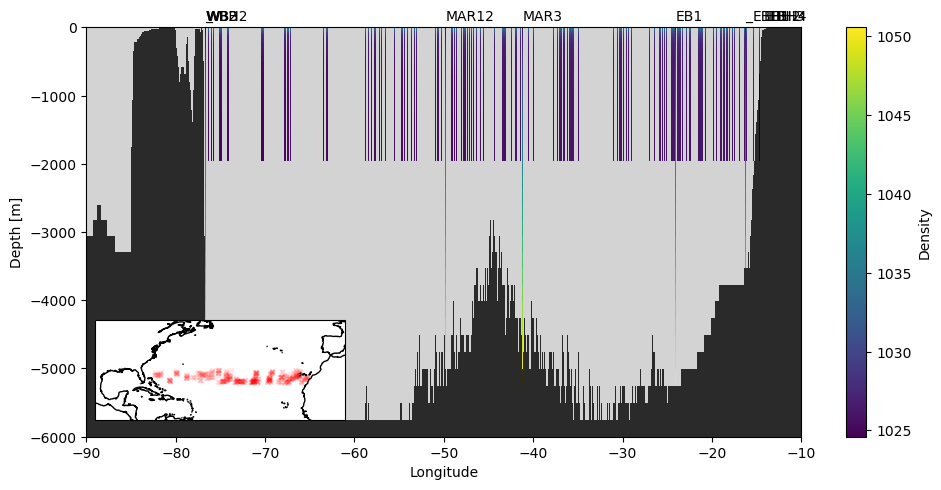

In [9]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1,1,1)

# set the background color of the plot to white
ax.set_facecolor('lightgrey')

bottom = mask_mesh.tmask.isel(y = np.abs(mask_mesh.nav_lat.mean('x') - 26.5).argmin().values[()]).values.astype(np.float32)

bottom[bottom == 1] = np.NaN

rho = ax.pcolormesh(lon_bins, ds_argo_merged.z, nan_image.T, cmap = 'viridis')
ax.pcolormesh(lon_bins, ds_argo_merged.z, bottom, cmap = 'grey', alpha=.8)


plt.colorbar(rho, ax = ax, label = 'Density')
ax.set_xlabel('Longitude')
ax.set_ylabel('Depth [m]')
ax.set_xlim(-90, -10)

# ax.set_title(f'{np.datetime_as_string(ds_argo_merged_10days.time[ts].values[()], unit="D")} - {np.datetime_as_string(ds_argo_merged_10days.time[ts+1].values[()], unit="D")}')


for m in mooring_ds.moorings:
    plt.text(m.nav_lon.values[()],100, m.values)

from cartopy import crs as ccrs
from cartopy import feature as cfeature


ax_inner = plt.axes([0.1, 0, .25, 0.5], projection=ccrs.PlateCarree(), transform = ax.transAxes, label='2')


# ax_inner = ax.inset_axes(
#     [0.1, 0.1, 0.1, 0.1], 
#     projection=ccrs.PlateCarree(),
#     transform=ax.transAxes, facecolor='white')

ax_inner.set_extent([-100,0,10,50], crs=ccrs.PlateCarree())

ax_inner.scatter(
    ds_argo_merged_10days.isel(time = ts).dropna('pos').lon.values,
    ds_argo_merged_10days.isel(time = ts).dropna('pos').lat.values,
    transform = ccrs.PlateCarree(),
    marker='x', s = 10, color = 'red', alpha=.1
)

ax_inner.add_feature(cfeature.COASTLINE)





fig.tight_layout()
plt.savefig('../rapid-geostrophic-reconstruction/argo_profiles.png', dpi = 300)

In [10]:
mooring_ds.moorings

<xarray.DataArray 'moorings' (moorings: 12)>
array(['_', 'WB3', '_', 'MAR12', 'MAR3', 'EBH4', 'EBH3', 'EBH2', 'EBH1', 'WB2',
       'WBH2', 'EB1'], dtype=object)
Coordinates:
    nav_lat   (moorings) float32 26.52 26.48 26.99 24.51 ... 26.57 26.48 24.52
    nav_lon   (moorings) float32 -76.75 -76.5 -16.25 ... -76.7 -76.65 -24.1
    x         (moorings) int64 434 439 1644 973 1145 ... 1685 1661 435 436 1487
    y         (moorings) int64 1275 1274 1285 1230 1230 ... 1287 1276 1274 1230
  * moorings  (moorings) object '_' 'WB3' '_' 'MAR12' ... 'WB2' 'WBH2' 'EB1'

## Train Val Test

In [66]:
int(np.median(test_indices))

177

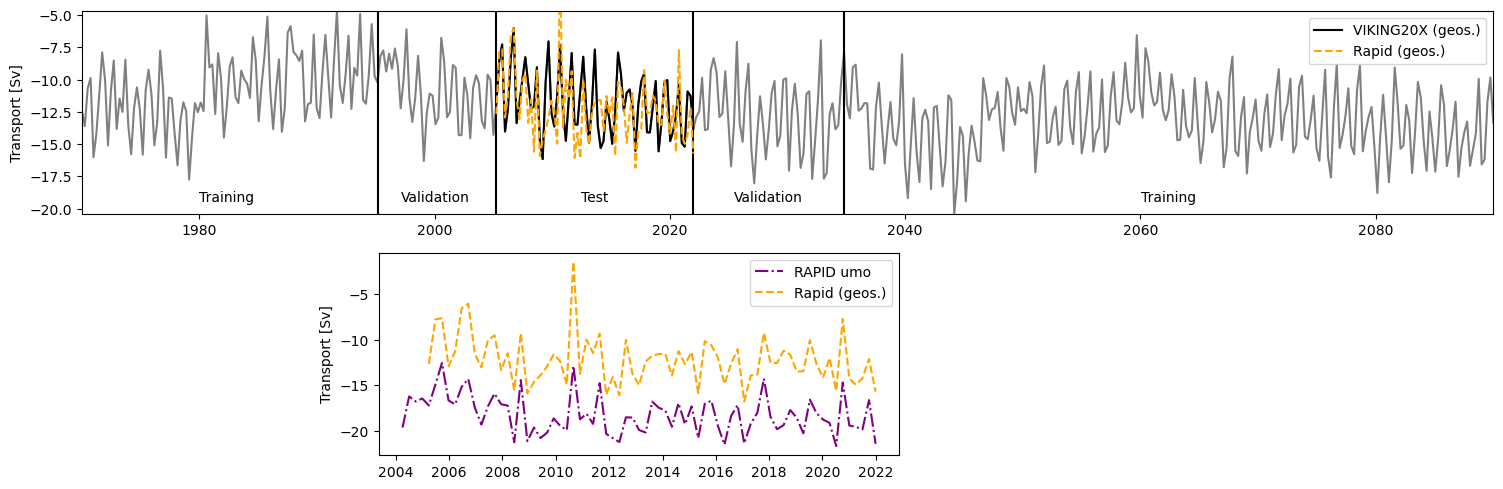

In [92]:
test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2005-01-01', '2022-01-01')).ti.values
# test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2055-01-01', None)).ti.values
valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('1995-01-01', '2005-01-01')).ti.values
valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2022-01-01','2035-01-01')).ti.values
val_indices = np.concatenate([valid_indices_1, valid_indices_2])
# val_indices =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2035-01-01', '2055-01-01')).ti.values


# test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2010-01-01', '2023-08-01')).ti.values
# valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2000-01-01', '2010-01-01')).ti.values
# valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2035-01-01')).ti.values
# val_indices = np.concatenate([valid_indices_1, valid_indices_2])





train_mask = ~np.isin(np.arange(t_umo_10days.time.shape[0]), np.concatenate((val_indices, test_indices)))
train_indices = np.arange(t_umo_10days.time.shape[0])[train_mask]



import matplotlib.pyplot as plt

ds_argo_merged_obs, t_umo_obs_obs = load_merged_argo_dataset_and_tumo_obs(time_smoothing)#, lat_bounds = lat_bounds)


# fig = plt.figure(figsize=(15,5))

## create mosaic of plots

fig, axes = plt.subplot_mosaic(
    """
    AAAAA
    .BB..
    """, figsize=(15,5))


ax = axes['A']

# train1 = t_umo_10days.isel(time = train_indices[train_indices <= 101]).dv_dz_times_X
# ax.plot(train1.time, train1.values, c = 'b', label = 'Train')
# train2 = t_umo_10days.isel(time = train_indices[train_indices > 101]).dv_dz_times_X
# ax.plot(train2.time, train2.values, c = 'b')


# val1 = t_umo_10days.isel(time = val_indices[val_indices < 150]).dv_dz_times_X
# val2 = t_umo_10days.isel(time = val_indices[val_indices > 150]).dv_dz_times_X

# ax.plot(val1.time, val1.values, c = 'g', label ='Validation')
# ax.plot(val2.time, val2.values, c = 'g')
ax.plot(t_umo_10days.time, t_umo_10days.dv_dz_times_X.values, c = 'grey')

ax.vlines(t_umo_10days.time[test_indices[0]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')
ax.vlines(t_umo_10days.time[test_indices[-1]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')
ax.vlines(t_umo_10days.time[val_indices[0]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')
ax.vlines(t_umo_10days.time[val_indices[-1]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')

ax.text(t_umo_10days.time[int(test_indices.mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Test', ha = 'center')
ax.text(t_umo_10days.time[int(val_indices[val_indices < 150].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Validation', ha = 'center')
ax.text(t_umo_10days.time[int(val_indices[val_indices > 150].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Validation', ha = 'center')
ax.text(t_umo_10days.time[int(train_indices[train_indices <= 101].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Training', ha = 'center')
ax.text(t_umo_10days.time[int(train_indices[train_indices > 101].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Training', ha = 'center')

test = t_umo_10days.isel(time = test_indices).dv_dz_times_X
ax.plot(test.time, test.values, c = 'k', label = 'VIKING20X (geos.)', alpha = 1)

ax.set_xlim(t_umo_10days.time.min().data, t_umo_10days.time.max().data)
ax.set_ylim(t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data)
# ax.set_xticklabels([])
# ax.set_title('VIKING20X (1st and 2nd cycle)')
ax.set_ylabel('Transport [Sv]')
ax.plot(t_umo_obs_obs.sel(time = slice(t_umo_10days.time[test_indices[0]],t_umo_10days.time[test_indices[-1]])).dv_dz_times_X.time, t_umo_obs_obs.sel(time = slice(t_umo_10days.time[test_indices[0]],t_umo_10days.time[test_indices[-1]])).dv_dz_times_X.values, c = 'orange', linestyle = '--', alpha = 1, label = 'Rapid (geos.)') 
ax.legend()


ax = axes['B']
# ax.set_xlim(t_umo_10days.time.min().data, t_umo_10days.time.max().data)
# ax.set_ylim(t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data)

# ax.set_title('RAPID')
ax.set_ylabel('Transport [Sv]')





rapid_moc = xr.open_dataset('../rapid-geostrophic-reconstruction/data/moc_transports.nc')
rapid_moc = rapid_moc.groupby(rapid_moc.time.dt.floor('90D')).mean().rename({'floor': 'time'})
ax.plot(rapid_moc.time, rapid_moc.t_umo10.values, c = 'purple', linestyle = '-.', label = 'RAPID umo') 


ax.plot(t_umo_obs_obs.sel(time = slice(t_umo_10days.time[test_indices[0]],t_umo_10days.time[test_indices[-1]])).dv_dz_times_X.time, t_umo_obs_obs.sel(time = slice(t_umo_10days.time[test_indices[0]],t_umo_10days.time[test_indices[-1]])).dv_dz_times_X.values, c = 'orange', linestyle = '--', alpha = 1, label = 'Rapid (geos.)') 

ax.legend()

fig.tight_layout()
fig.savefig('../rapid-geostrophic-reconstruction/train_val_test_split.png')

### Mooring cuts

In [18]:
ds_pos_obs = xr.open_dataset(dataset_path / ref_folder/ f'ds_pos_obs.nc')
ds_pos_obs = ds_pos_obs.groupby(ds_pos_obs.time.dt.floor('90D')).mean().rename({'floor': 'time'})

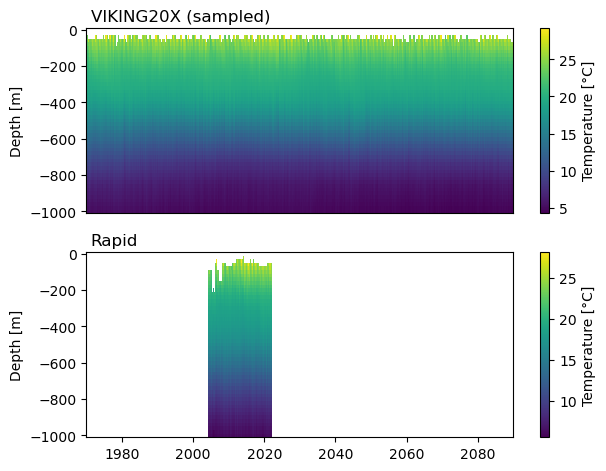

In [180]:
fig = plt.figure()
ax = fig.add_subplot(2,1,1)


time_min = t_umo_10days.time.min().data
time_max = t_umo_10days.time.max().data

sim_values = ds_pos_sim.sel(pos = 'west', z = slice(0, -1000)).temperature
simmesh = ax.pcolormesh(sim_values.time, sim_values.z, sim_values.values.T)

ax.set_xlim(time_min, time_max)
ax.set_ylabel('Depth [m]')
ax.set_xticks([])

ax.text(0.01, 1.1, 'VIKING20X (sampled)', transform=ax.transAxes, fontsize=12, verticalalignment='top')
plt.colorbar(simmesh, ax = ax, label = 'Temperature [°C]')

ax = fig.add_subplot(2,1,2)
obs_values = ds_pos_obs.sel(pos = 'west', z = slice(0, -1000)).temperature
obsmesh = ax.pcolormesh(obs_values.time, obs_values.z, obs_values.values.T)
#.plot(ax = ax, x = 'time', y = 'z', cmap = 'viridis')
ax.set_ylabel('Depth [m]')
ax.text(0.01, 1.1, 'Rapid', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(time_min, time_max)

plt.colorbar(obsmesh, ax = ax, label = 'Temperature [°C]')

fig.tight_layout()
fig.savefig('../rapid-geostrophic-reconstruction/temperature_profile.png')


# Study Area Figure

In [7]:
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from cartopy import feature as cfeature

In [55]:
stream_function = load_dataset_from_grid_type('moc', [2015,2016], True, 'VIKING20X.L46-KFS003', '1d', folder = 'derived')
stream_function_monthly = stream_function.groupby(stream_function.time_counter.dt.floor('30D')).mean().rename({'floor': 'time'})
stream_function_monthly = stream_function_monthly.isel(time = 3).compute()


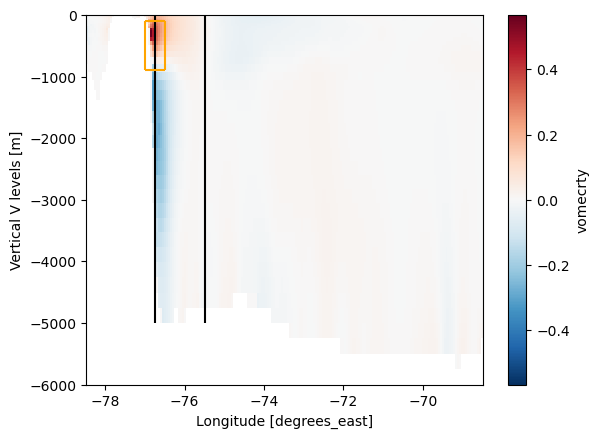

In [106]:
V_grid = load_dataset_from_grid_type('V', (2007, 2015), nest = True, model = 'VIKING20X.L46-KFS003', delta_t = '1m', chunks={"time_counter" : None,"y": 20, "x": 300})
V_grid_loaded = V_grid.isel(y = 1274).isel(x = slice(400,2000)).vomecrty.compute()

mask_mesh, mask_glo = load_masks(nest = True, model = 'VIKING20X.L46-KFS003')
mask_mesh_loaded = mask_mesh.isel(y = 1274).isel(x = slice(400,2000)).tmask.compute()

import matplotlib.pyplot as plt


In [137]:
ds_argo_merged_obs, t_umo_obs_obs = load_merged_argo_dataset_and_tumo_obs(time_smoothing)#, lat_bounds = lat_bounds)


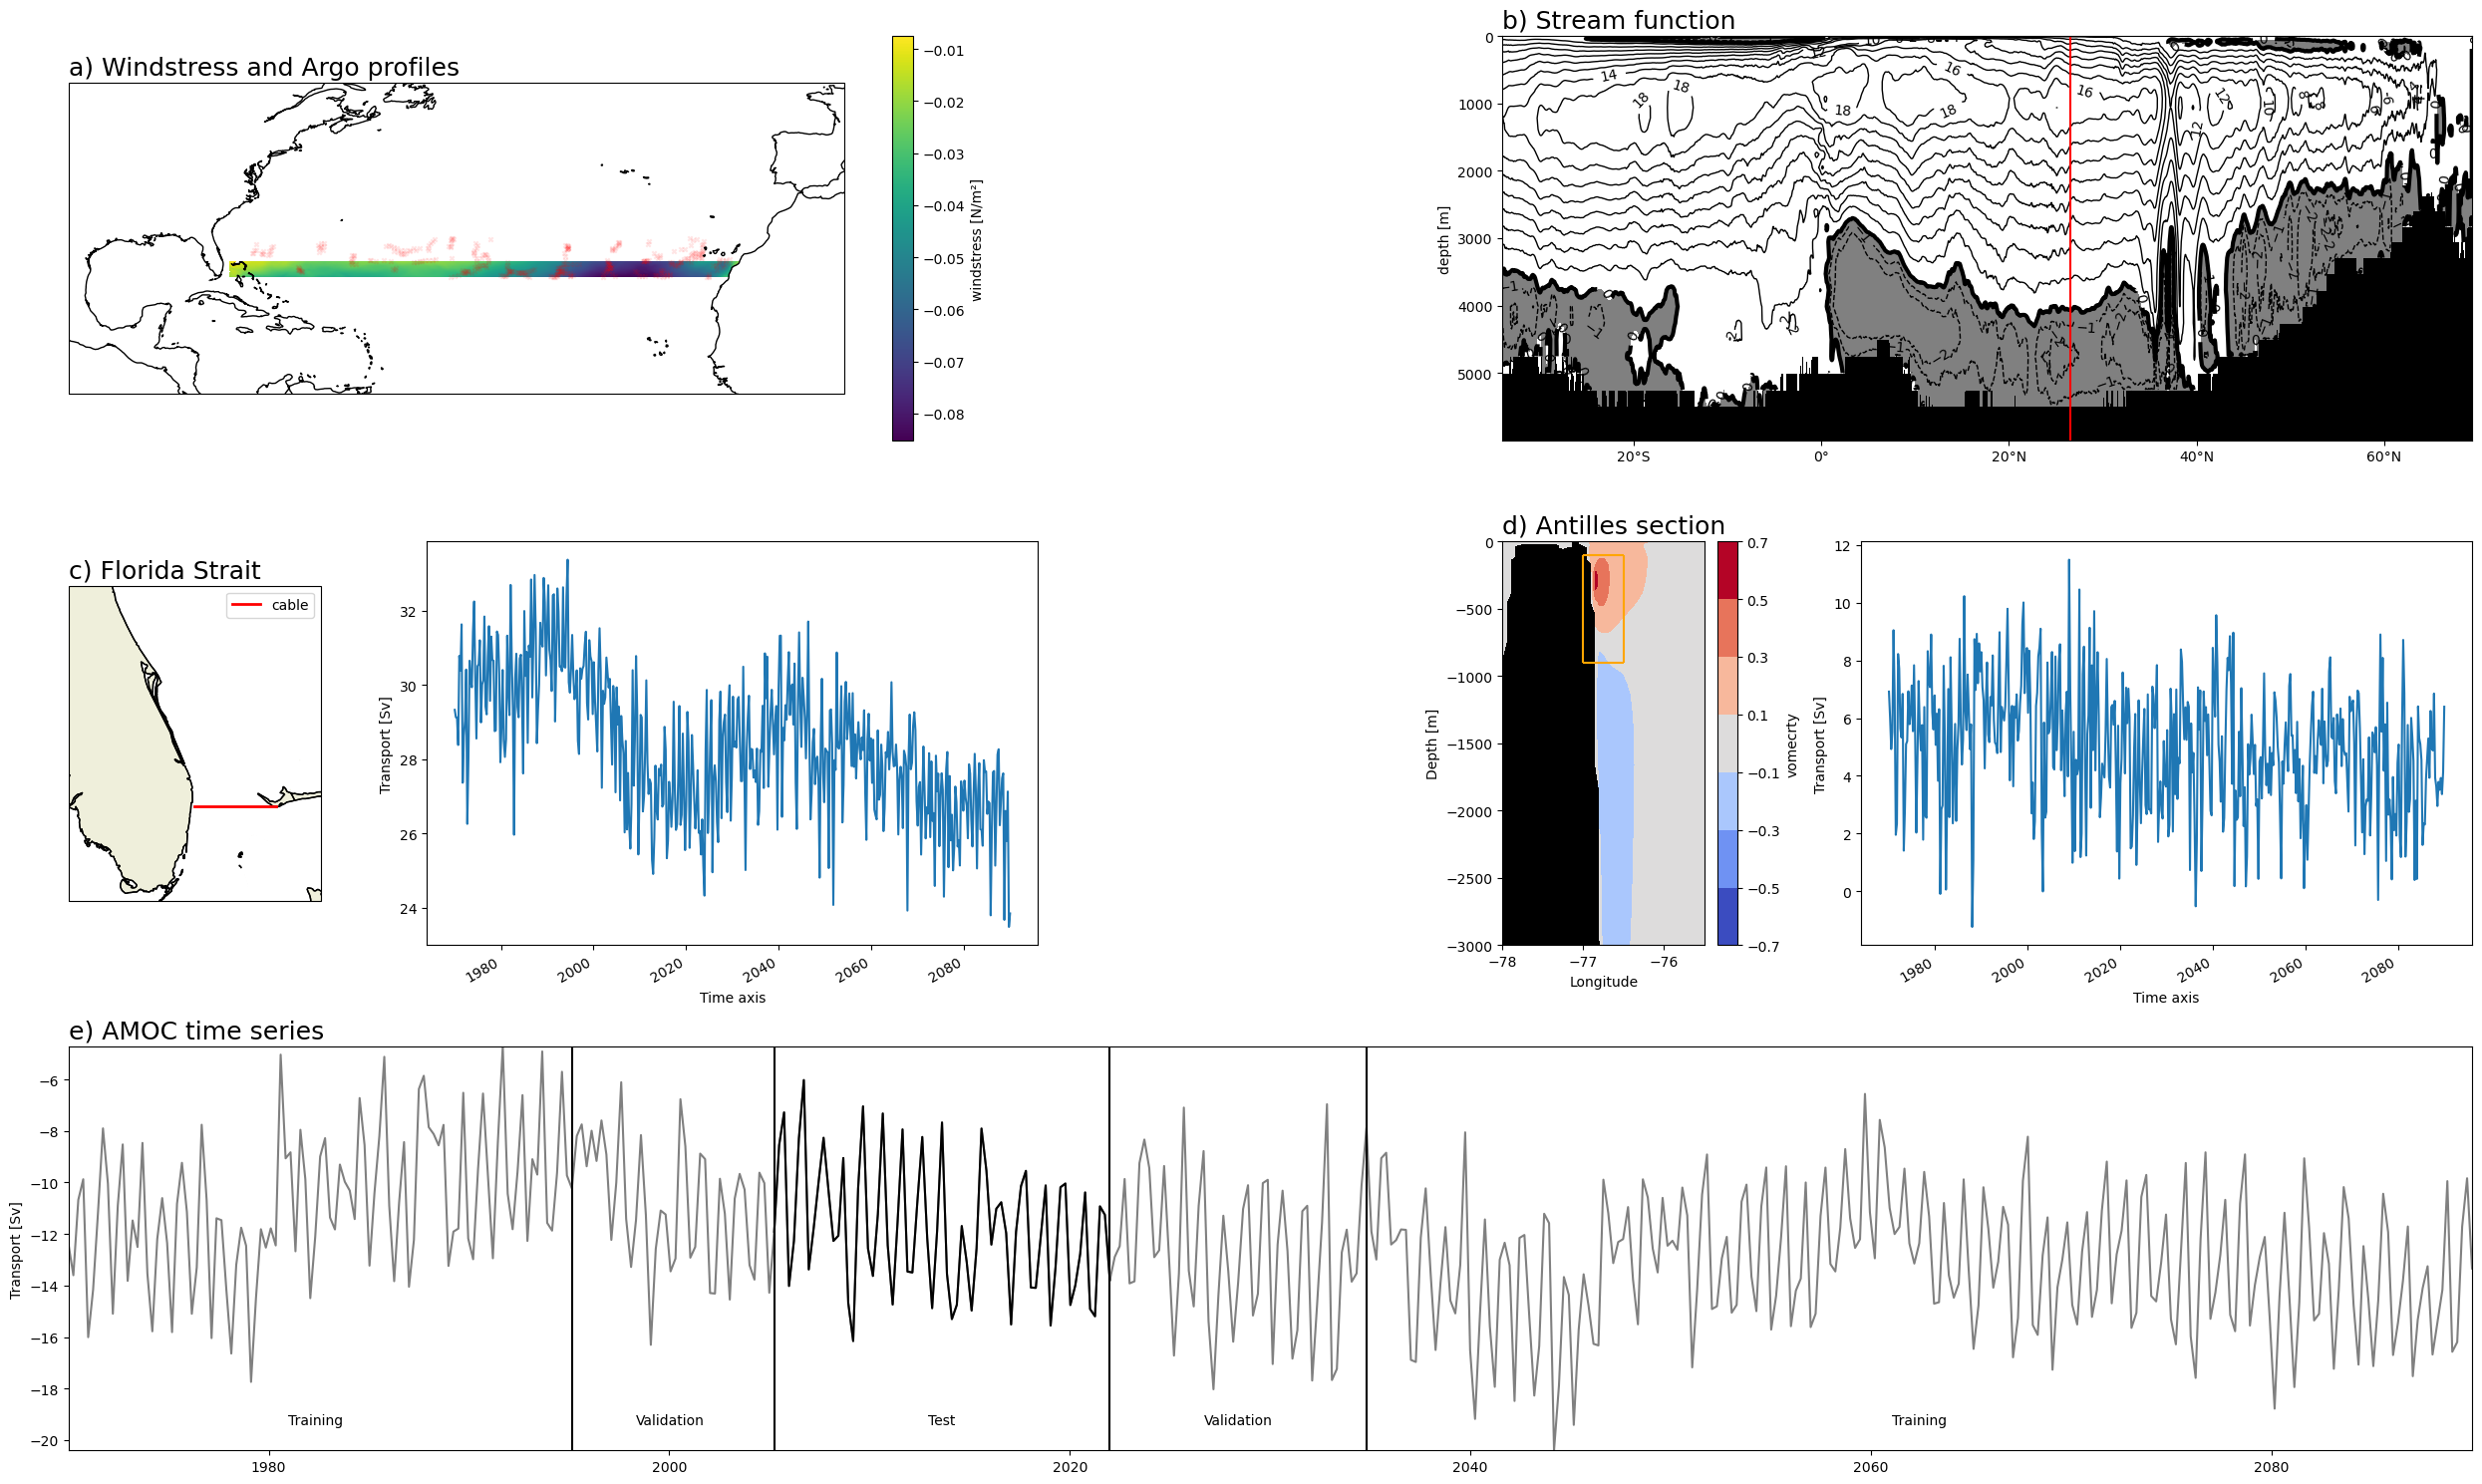

In [165]:
fig = plt.figure(figsize=(25,15))


axes = fig.subplot_mosaic(
    """
    AAA.BBB
    CDD.EFF
    GGGGGGG
    """,
    per_subplot_kw = {
        'AC': {'projection': ccrs.PlateCarree()},
    }
)




## Windstress and Argos 
ax = axes['A']


windstress = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/windstress/sozotaux_2527N_8010W_KFS003-1st_70None.nc')
monthly_windstress = windstress.groupby(windstress.time_counter.dt.floor('30D')).mean().rename({'floor': 'time'})

monthly_windstress = monthly_windstress.isel(time = 550)
taux = ax.pcolormesh(monthly_windstress.nav_lon, monthly_windstress.nav_lat, monthly_windstress.values, transform=ccrs.PlateCarree(), cmap = 'viridis')






ax.scatter(
    ds_argo_merged_10days.isel(time = ts).dropna('pos').lon.values,
    ds_argo_merged_10days.isel(time = ts).dropna('pos').lat.values,
    transform = ccrs.PlateCarree(),
    marker='x', s = 10, color = 'red', alpha=.1
)



ax.set_extent([-100,0,10,50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

plt.colorbar(taux, ax = ax, label = 'windstress [N/m²]')

ax.set_title('a) Windstress and Argo profiles', loc='left', fontsize = 18)


## Stream function
ax = axes['B']


ax.set_facecolor('black')
areas = ax.contourf(stream_function_monthly.squeeze().nav_lat, stream_function_monthly.squeeze().depthw, stream_function_monthly.squeeze().zomsfatl.where(mask_mesh.tmask.rename(z ='depthw').sum('x') > 100), levels = 0, colors = ['grey', 'white'])


zero_contour = ax.contour(stream_function_monthly.squeeze().nav_lat, stream_function_monthly.squeeze().depthw, stream_function_monthly.squeeze().zomsfatl.where(mask_mesh.tmask.rename(z ='depthw').sum('x') > 100), colors = 'black', levels = 0, linewidths = 3)

strike_contour = ax.contour(stream_function_monthly.squeeze().nav_lat, stream_function_monthly.squeeze().depthw, stream_function_monthly.squeeze().zomsfatl.where(mask_mesh.tmask.rename(z ='depthw').sum('x') > 100), colors = 'black', levels = [-2, -1] + list(range(2, 20, 2)), linewidths = 1)


ax.clabel(strike_contour, strike_contour.levels, inline=True, fontsize=10)
ax.clabel(zero_contour, zero_contour.levels, inline=True, fontsize=10)

ax.set_ylabel('depth [m]')

ax.set_xticks([-20, 0, 20, 40, 60], ['20°S', '0°', '20°N', '40°N', '60°N'])

ax.set_yticks(np.arange(0, 6000, 1000) * -1,np.arange(0, 6000, 1000))

ax.vlines(26.5, -6000, 0, colors='red')
ax.set_ylim(-6000, 0)

ax.set_title('b) Stream function', loc='left', fontsize = 18)

## Florida strait map
ax = axes['C']


ax.plot([-80, -78.7], [26.5, 26.5], transform = ccrs.PlateCarree(), linewidth = 2, color = 'red')
ax.legend(['cable'])
plt.title('')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.STATES)
ax.set_extent((-82, -78, 25, 30))
ax.set_title('c) Florida Strait', loc='left', fontsize = 18)
##Florida strait time series
ax = axes['D']


(florida_current.sobarstf / 1e6).plot(ax = ax)

ax.set_ylabel('Transport [Sv]')


## Antilles depth section
ax = axes['E']


V_grid_loaded.mean('time_counter').where(mask_mesh_loaded.rename({'z': 'depthv'}) == 1).assign_coords(z = -V_grid_loaded.depthv).isel(x = slice(0,200)).plot.contourf(x = 'nav_lon', y = 'z', ax = ax, levels = [-.7,-.5, -.3, -.1, .1, .3, .5, .7], cmap = 'coolwarm')

ax.set_facecolor('black')


# ax.vlines(-75.5,-5000,0, color = 'black')
# ax.vlines(-76.74,-5000,0, color = 'black')


ax.vlines(-77,-900,-100, color = 'orange')
ax.vlines(-76.5,-900,-100, color = 'orange')
ax.hlines(-900, -77, -76.5, color = 'orange')
ax.hlines(-100, -77, -76.5, color = 'orange')

ax.set_xlim(-78, -75.5)
ax.set_ylim(-3000, 0)
ax.set_ylabel('Depth [m]')
ax.set_xlabel('Longitude')

ax.set_title('d) Antilles section', loc='left', fontsize = 18)


## Antilles time series
ax = axes['F']

(antilles_current.__xarray_dataarray_variable__ ).plot(ax = ax)
ax.set_ylabel('Transport [Sv]')


## AMOC time series with train, val, and test
ax = axes['G']


test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2005-01-01', '2022-01-01')).ti.values
valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('1995-01-01', '2005-01-01')).ti.values
valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2022-01-01','2035-01-01')).ti.values
val_indices = np.concatenate([valid_indices_1, valid_indices_2])





train_mask = ~np.isin(np.arange(t_umo_10days.time.shape[0]), np.concatenate((val_indices, test_indices)))
train_indices = np.arange(t_umo_10days.time.shape[0])[train_mask]

ax.plot(t_umo_10days.time, t_umo_10days.dv_dz_times_X.values, c = 'grey')

ax.vlines(t_umo_10days.time[test_indices[0]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')
ax.vlines(t_umo_10days.time[test_indices[-1]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')
ax.vlines(t_umo_10days.time[val_indices[0]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')
ax.vlines(t_umo_10days.time[val_indices[-1]], t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data, color = 'k', linestyle = '-')

ax.text(t_umo_10days.time[int(test_indices.mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Test', ha = 'center')
ax.text(t_umo_10days.time[int(val_indices[val_indices < 150].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Validation', ha = 'center')
ax.text(t_umo_10days.time[int(val_indices[val_indices > 150].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Validation', ha = 'center')
ax.text(t_umo_10days.time[int(train_indices[train_indices <= 101].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Training', ha = 'center')
ax.text(t_umo_10days.time[int(train_indices[train_indices > 101].mean())], t_umo_10days.dv_dz_times_X.min().data + 1, 'Training', ha = 'center')

test = t_umo_10days.isel(time = test_indices).dv_dz_times_X
ax.plot(test.time, test.values, c = 'k', label = 'VIKING20X (geos.)', alpha = 1)

ax.set_xlim(t_umo_10days.time.min().data, t_umo_10days.time.max().data)
ax.set_ylim(t_umo_10days.dv_dz_times_X.min().data, t_umo_10days.dv_dz_times_X.max().data)
# ax.set_xticklabels([])
# ax.set_title('VIKING20X (1st and 2nd cycle)')
ax.set_ylabel('Transport [Sv]')
# ax.plot(t_umo_obs_obs.sel(time = slice(t_umo_10days.time[test_indices[0]],t_umo_10days.time[test_indices[-1]])).dv_dz_times_X.time, t_umo_obs_obs.sel(time = slice(t_umo_10days.time[test_indices[0]],t_umo_10days.time[test_indices[-1]])).dv_dz_times_X.values, c = 'orange', linestyle = '--', alpha = 1, label = 'Rapid (geos.)') 
# ax.legend()
ax.set_title('e) AMOC time series', loc='left', fontsize = 18)

fig.tight_layout()
plt.savefig('../rapid-geostrophic-reconstruction/figs/overview.png', dpi = 300)

## Intro figure

In [8]:
import pandas as pd
from pathlib import Path
from datetime import datetime
from torch.utils.data import DataLoader
from amoc_reconstruction.reconstruction.model import init_assignment_module
from amoc_reconstruction.reconstruction.model import ProfileModelSUSTeR5_fast, ProfileModelSUSTeR6, ProfileModelSUSTeR7
from amoc_reconstruction.train import train, make_predictions
from amoc_reconstruction.reconstruction.dataset import merge_profiles_max_profiles
from amoc_reconstruction.reconstruction.dataset import load_merged_argo_dataset_and_tumo_cycles, filter_ds_argo_data, split_dataset_into_training_validation_testing_profile_datasets, load_merged_argo_dataset_and_tumo
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

In [9]:
### PARAMETERS

smoothing_days = 90

time_smoothing = f'{smoothing_days}D'
lat_bounds = (25, 30)

target_reference_level = 4800



missing_values_in_target = False
using_missing_indices = False
using_transport_from_previous_year = False
use_deep_dvdz = False
deep_argo = True

geostrophic_prediction = False


train_batch_sizes = {
    '10D': 32,
    '30D': 16,
    '90D': 8,
    '365D': 4,
}


n_compartments_for_smoothing = {
    '10D': 49,
    '30D': 3,
    '90D': 9,
    '365D': 42,
}

train_batch_size = train_batch_sizes[time_smoothing]

add_tmp = False
add_sal = False

test_start_year = 2005
test_end_year = 2025

validation_years_on_each_side = 10


random_split_data = False

assert target_reference_level in [2000, 4800], "Only 2000 and 4800 are supported as reference levels"
version = 'v5'
n_compartments = n_compartments_for_smoothing[time_smoothing]
n_embedding = 8

distance_assignment_module  = 'distance'

experiment_path = Path(f'../rapid-geostrophic-reconstruction/figs/experiment_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_{smoothing_days}_days/argo_after_2012/paperdraft/')

total_moc_path = Path('../rapid-geostrophic-reconstruction/datasets/moc_total/')
antilles_current_path = Path('../rapid-geostrophic-reconstruction/datasets/antilles_current/')
florida_current_path = Path('../rapid-geostrophic-reconstruction/datasets/florida_current/')
wind_stress_path = Path('../rapid-geostrophic-reconstruction/datasets/windstress/')

ref_folder = f'{abs(target_reference_level)}m_ref'

compartments = [
        ['west_p', -76.74, -70, 'west'],
        ['mar_west_p', -60, -47, 'east'],
        ['mar_east_p', -47, -40, 'west'],
        ['east_p', -30, -13.5, 'east']
    ]


device = 'cpu'


assert version in ['v2', 'v3', 'v4', 'v5']
assert distance_assignment_module in ['distance', 'fixed']



In [10]:
import numpy as np
# print([np.datetime64('1958-01-01') + t_delta[i] + np.timedelta64(365, 'D') for i in range(len(t_delta))])

In [11]:
ds_argo_merged_cycles_365D = []
t_umo_obs_cycles_365D = []
ds_pos_cycles_365D = []
dv_dz_cycles_365D = []
total_moc_cycles_365D = []
antilles_current_cycles_365D = []
florida_current_cycles_365D = []
wind_stress_cycles_365D = []

for suffix in   ['1st_7024', '2nd_5824', '3rd_5824', '4th_5824', '5th_5824', '6th_5824']:
    ds_argo_merged_cycle, t_umo_obs_cycle, ds_pos_cycle, dv_dz_cycle, total_moc_cycle, antilles_current_cycle, florida_current_cycle, wind_stress_cycle = load_merged_argo_dataset_and_tumo(
        '365D', 
        Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_365_days/argo_after_2012/paperdraft/'),
        ref_folder,
        total_moc_path,
        antilles_current_path,
        florida_current_path,
        wind_stress_path,
        missing_values_in_target= missing_values_in_target,
        suffix= suffix, 
        deep_argo = deep_argo
    )

    ds_argo_merged_cycles_365D.append(ds_argo_merged_cycle)
    t_umo_obs_cycles_365D.append(t_umo_obs_cycle)
    ds_pos_cycles_365D.append(ds_pos_cycle)
    dv_dz_cycles_365D.append(dv_dz_cycle)
    total_moc_cycles_365D.append(total_moc_cycle)
    antilles_current_cycles_365D.append(antilles_current_cycle)
    florida_current_cycles_365D.append(florida_current_cycle)
    wind_stress_cycles_365D.append(wind_stress_cycle)
    

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/p

In [12]:
ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta, total_moc, antilles_current, florida_current, wind_stress, backwards_timeshift = load_merged_argo_dataset_and_tumo_cycles(
    ['1st_7024', '2nd_5824'],#, '3rd_5824', '4th_5824', '5th_5824', '6th_5824'],
    dataset_path,
    ref_folder,
    total_moc_path,
    antilles_current_path,
    florida_current_path,
    wind_stress_path,
    time_smoothing,
    deep_argo,
    missing_values_in_target
)


ds_argo_merged = filter_ds_argo_data(ds_argo_merged, False)



train_dataset, val_dataset, test_dataset, (total_moc_mean, total_moc_std, geostrophic_moc_mean, geostorphic_moc_std) = split_dataset_into_training_validation_testing_profile_datasets(
    False, test_start_year, test_end_year, validation_years_on_each_side, t_umo_obs, ds_argo_merged, add_tmp, add_sal, deep_argo, False, total_moc, florida_current, antilles_current, wind_stress, dv_dz_obs, missing_values_in_target, ds_pos_sim, compartments, time_smoothing, lat_bounds, using_transport_from_previous_year, using_missing_indices, use_deep_dvdz, backwards_timeshift
)


dl = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, collate_fn=merge_profiles_max_profiles, num_workers=0)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=0)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=0)


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


142 222 2005-03-28T00:00:00.000000000 2024-12-13T00:00:00.000000000
325 81 81


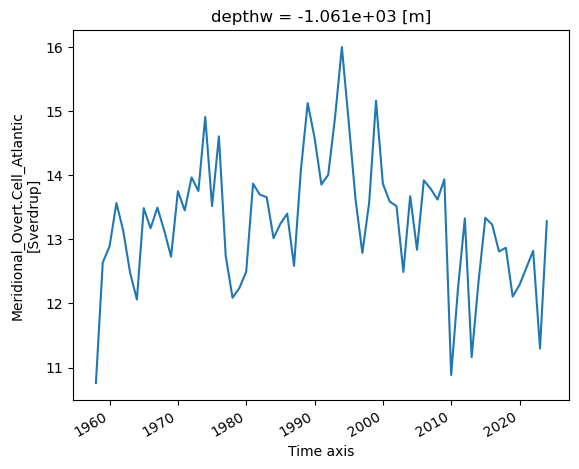

In [13]:
import xarray as xr
third_cycle_moc = xr.open_dataset(
    '../rapid-geostrophic-reconstruction/datasets/moc_total/cdf_moc_265N_KFS003-3rd_5824.nc'
)

third_cycle_moc = third_cycle_moc.sel(depthw = -1000, method = 'nearest')

atl_trans = third_cycle_moc.groupby(third_cycle_moc['time_counter'].dt.round('365D')).mean().rename({'round': 'time'}).zomsfatl
atl_trans.plot()

In [14]:
V_grid_1cycle = load_dataset_from_grid_type('V', (1970, 2020), nest = True, model = 'VIKING20X.L46-KFS003', delta_t = '1m', chunks={"time_counter" : None,"y": -1, "x": -1})
# V_grid_2cycle = load_dataset_from_grid_type('V', (None, 2020), nest = True, model = 'VIKING20X.L46-KFS003', delta_t = '1m', chunks={"time_counter" : None,"y": 200, "x": -1})

# V_grid = xr.concat([V_grid_1cycle, V_grid_2cycle], dim = 'time_counter')
V_grid = V_grid_1cycle

V_grid_loaded = V_grid.isel(y = 1274).isel(x = slice(400,700)).vomecrty.mean('time_counter').compute()
V_grid_loaded

<xarray.DataArray 'vomecrty' (depthv: 46, x: 300)>
array([[ 2.3156849e-03,  4.8637548e-03,  8.2424413e-03, ...,
         2.7985836e-03,  2.6035584e-03,  2.4675762e-03],
       [-2.6973763e-03, -1.4546026e-04,  3.2696917e-03, ...,
        -2.5618493e-03, -2.7598918e-03, -2.8968432e-03],
       [-5.8740824e-03, -3.3130529e-03,  5.1843574e-05, ...,
        -7.0008994e-03, -7.2009899e-03, -7.3376042e-03],
       ...,
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         3.0925998e-03,  3.5186203e-03,  2.9353595e-03],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)
Coordinates:
    nav_lat  (x) float32 26.5 26.5 26.5 26.5 26.5 ... 26.51 26.51 26.51 26.51
    nav_lon  (x) float32 -78.45 -78.4 -78.35 -78.3 ... -63.65 -63.6 -63.55 -63.5
  * depthv   (depthv) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
Dimensions without coordinates: x

In [15]:
mask_mesh, mask_glo = load_masks(nest = True, model = 'VIKING20X.L46-KFS003')
mask_mesh_loaded = mask_mesh.isel(y = 1274).isel(x = slice(400,700)).tmask.compute()

In [16]:
stream_function_1cycle = load_dataset_from_grid_type('moc', [1970,2020], True, 'VIKING20X.L46-KFS003', '1m', folder = 'derived', chunks={"time_counter" : -1,"y": None, "x": 1})
stream_function_2cycle = load_dataset_from_grid_type('moc', [None,2020], True, 'VIKING20X.L46-KFS003-2nd', '1m', folder = 'derived', chunks={"time_counter" : -1,"y": None, "x": 1})
# stream_function_monthly = stream_function.groupby(stream_function.time_counter.dt.floor('30D')).mean().rename({'floor': 'time'})
# stream_function_monthly = stream_function_monthly.isel(time = 3).compute()
stream_function_both_cycles = xr.concat([stream_function_1cycle, stream_function_2cycle], dim = 'time_counter')

In [17]:
averaged_stream_function_both_cycles = stream_function_both_cycles.mean('time_counter').compute()

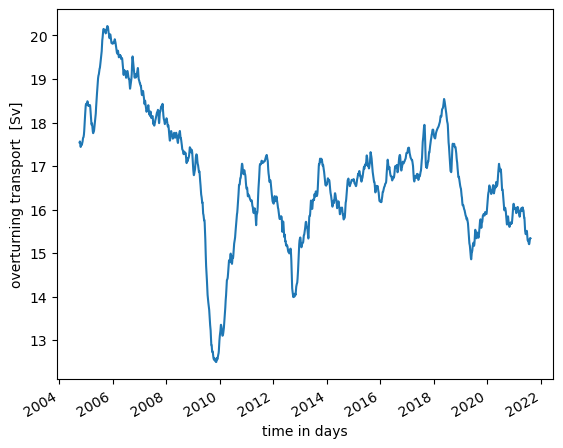

In [18]:
rapid_moc = xr.open_dataset('../rapid-geostrophic-reconstruction/data/moc_transports.nc')
rapid_moc = rapid_moc.rolling(time=2*365, center=True).mean()
rapid_moc.moc_mar_hc10.plot()


In [19]:
t_umo_obs

<xarray.Dataset>
Dimensions:        (time: 487)
Coordinates:
    z              float64 -1e+03
  * time           (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2090-01-01
Data variables:
    dv_dz_times_X  (time) float64 -19.96 -18.72 -18.03 ... -21.48 -18.52 -19.11

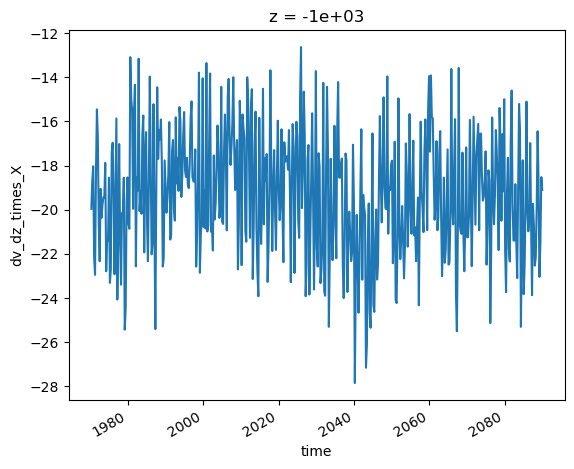

In [20]:
t_umo_obs.dv_dz_times_X.plot()

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:511: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)


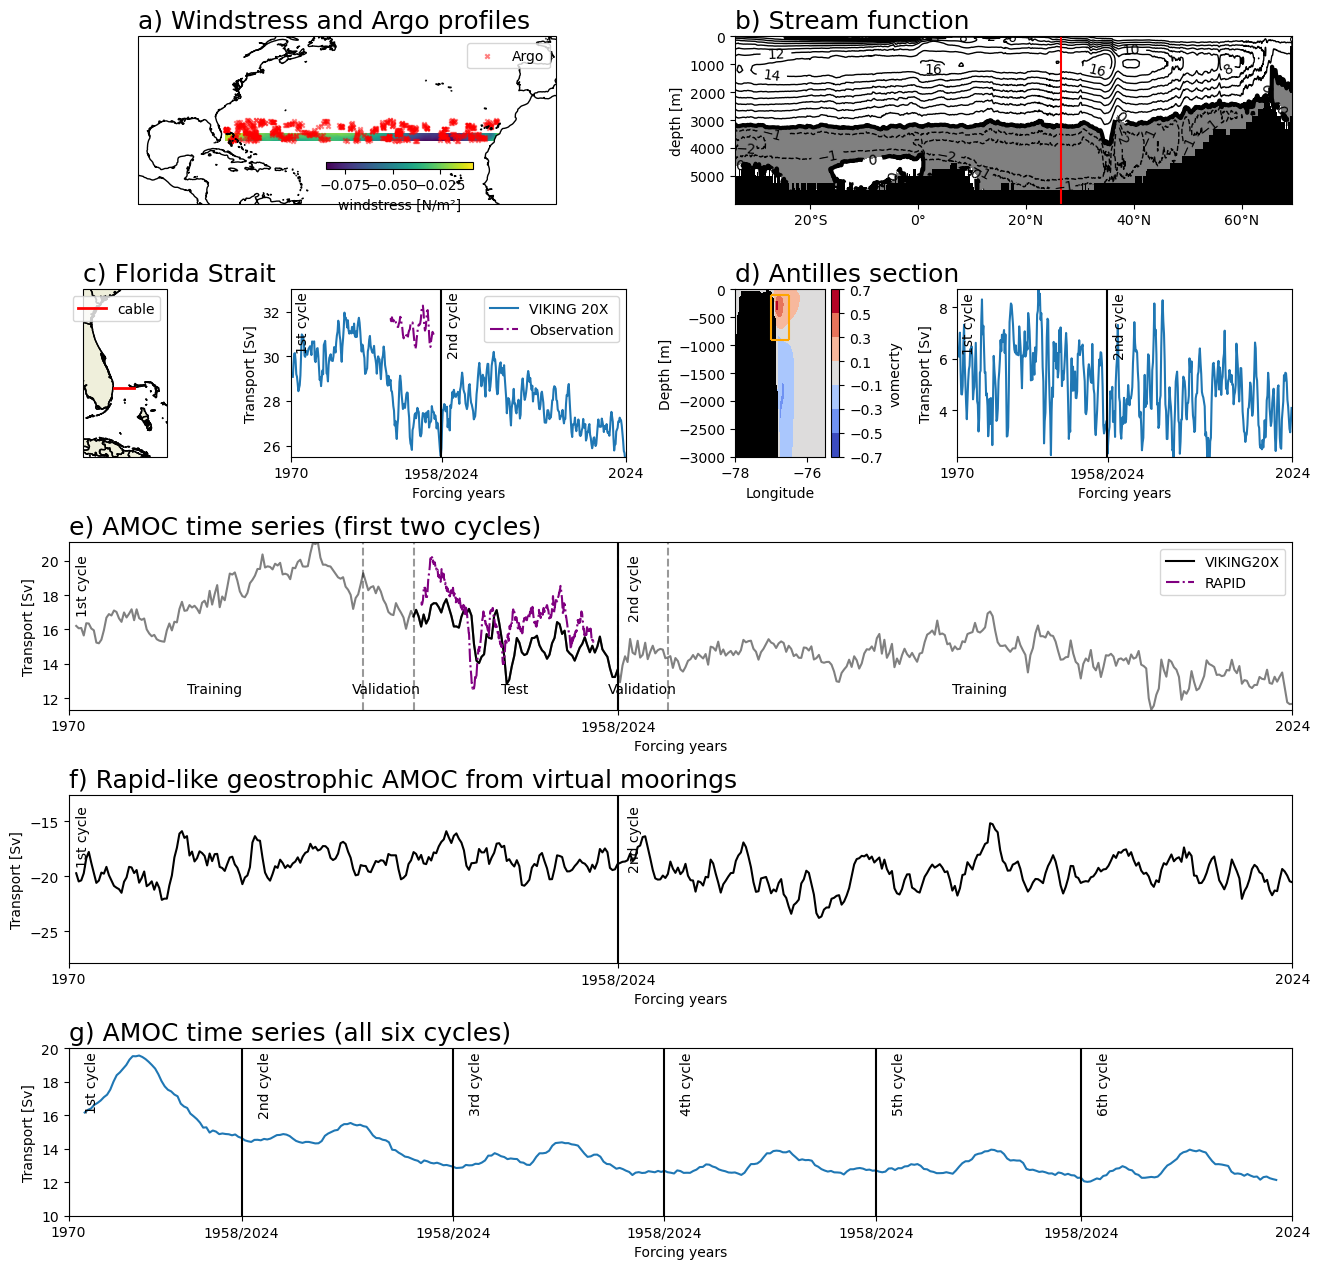

In [21]:
fig = plt.figure(figsize=(13.3,12.8))

ts = 110

axes = fig.subplot_mosaic(
    """
    AAABBB
    CDDEFF
    GGGGGG
    IIIIII
    HHHHHH
    """,
    per_subplot_kw = {
        'AC': {'projection': ccrs.PlateCarree()},
    }
)




## Windstress and Argos 
ax = axes['A']


windstress = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/windstress/sozotaux_2527N_8010W_KFS003-1st_70None.nc')
monthly_windstress = windstress.groupby(windstress.time_counter.dt.floor('30D')).mean().rename({'floor': 'time'})

monthly_windstress = monthly_windstress.isel(time = 550)
taux = ax.pcolormesh(monthly_windstress.nav_lon, monthly_windstress.nav_lat, monthly_windstress.values, transform=ccrs.PlateCarree(), cmap = 'viridis')






ax.scatter(
    ds_argo_merged.isel(time = ts).where(ds_argo_merged.isel(time = ts).profile_mask.sum('z') > 0, drop = True).lon.values,
    ds_argo_merged.isel(time = ts).where(ds_argo_merged.isel(time = ts).profile_mask.sum('z') > 0, drop = True).lat.values,
    transform = ccrs.PlateCarree(),
    marker='x', s = 10, color = 'red', alpha=.5, label = 'Argo'
)

ax.legend()

ax.set_extent([-100,0,10,50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

# cax = ax.inset_axes([0.05, 0.05, 0.9, 0.25], transform=ax.transAxes)
cax = ax.inset_axes([0.45, 0.21, 0.35, 0.04])
fig.colorbar(taux, cax = cax, label = 'windstress [N/m²]', orientation='horizontal')

ax.set_title('a) Windstress and Argo profiles', loc='left', fontsize = 18)


## Stream function
ax = axes['B']

stream_function = averaged_stream_function_both_cycles
ax.set_facecolor('black')
areas = ax.contourf(stream_function.squeeze().nav_lat, stream_function.squeeze().depthw, stream_function.squeeze().zomsfatl.where(mask_mesh.tmask.rename(z ='depthw').sum('x') > 100), levels = 0, colors = ['grey', 'white'])


zero_contour = ax.contour(stream_function.squeeze().nav_lat, stream_function.squeeze().depthw, stream_function.squeeze().zomsfatl.where(mask_mesh.tmask.rename(z ='depthw').sum('x') > 100), colors = 'black', levels = 0, linewidths = 3)

strike_contour = ax.contour(stream_function.squeeze().nav_lat, stream_function.squeeze().depthw, stream_function.squeeze().zomsfatl.where(mask_mesh.tmask.rename(z ='depthw').sum('x') > 100), colors = 'black', levels = [-2, -1] + list(range(2, 20, 2)), linewidths = 1)


ax.clabel(strike_contour, strike_contour.levels, inline=True, fontsize=10)
ax.clabel(zero_contour, zero_contour.levels, inline=True, fontsize=10)

ax.set_ylabel('depth [m]')

ax.set_xticks([-20, 0, 20, 40, 60], ['20°S', '0°', '20°N', '40°N', '60°N'])

ax.set_yticks(np.arange(0, 6000, 1000) * -1,np.arange(0, 6000, 1000))

ax.vlines(26.5, -6000, 0, colors='red')
ax.set_ylim(-6000, 0)

ax.set_title('b) Stream function', loc='left', fontsize = 18)

## Florida strait map
ax = axes['C']




ax.plot([-80, -78.7], [26.5, 26.5], transform = ccrs.PlateCarree(), linewidth = 2, color = 'red')
ax.legend(['cable'])
plt.title('')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.STATES)
ax.set_extent((-82, -76.5, 22, 33))
ax.set_title('c) Florida Strait', loc='left', fontsize = 18)




##Florida strait time series
ax = axes['D']

# (florida_current.sobarstf / 1e6).groupby(florida_current['time'].dt.round('365D')).mean().rename({'round': 'time'}).plot(ax = ax, label = 'VIKING 20X')
smoothed_florida = (florida_current.sobarstf / 1e6).rolling(time = 4, center = True).mean()
smoothed_florida.plot(ax = ax, label = 'VIKING 20X')
# florida_obs = xr.open_dataset('data/observations/florida.nc').__xarray_dataarray_variable__
# florida_obs = florida_obs.groupby(florida_obs['time'].dt.round('365D')).mean().rename({'round': 'time'})
# florida_obs.plot(ax = ax, label = 'Observation')

rapid_moc.t_gs10.resample(time = '90D').mean().rolling(time = 4).mean().plot(ax = ax, label = 'Observation',c = 'purple', linestyle = '-.',)

ax.vlines(smoothed_florida.time.sel(time = '2024-01-01', method = 'nearest'), 25.5,33, color = 'k', linestyle = '-')
ax.set_ylim(25.5, 33)
ax.set_xlim(smoothed_florida.time.min().data, smoothed_florida.time.max().data)
ax.text(smoothed_florida.time.sel(time = '1972-01-01', method = 'nearest'), 32.9, '1st cycle', rotation=90, verticalalignment = 'top')
ax.text(smoothed_florida.time.sel(time = '2026-01-01', method = 'nearest'), 32.9, '2nd cycle', rotation=90, verticalalignment = 'top')

# set x tickslabels 01-01-1970 to 1970, '01-01-2024' to '1958/2024'
ax.set_xticks([np.datetime64('1970-01-01'), np.datetime64('2024-01-01'), np.datetime64('2090-01-01')], ['1970', '1958/2024', '2024'], rotation = 'horizontal')

for label in ax.get_xticklabels():
    label.set_horizontalalignment('center')

ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Forcing years')
ax.legend()


## Antilles depth section
ax = axes['E']


V_grid_loaded.where(mask_mesh_loaded.rename({'z': 'depthv'}) == 1).assign_coords(z = -V_grid_loaded.depthv).isel(x = slice(0,200)).plot.contourf(x = 'nav_lon', y = 'z', ax = ax, levels = [-.7,-.5, -.3, -.1, .1, .3, .5, .7], cmap = 'coolwarm')

ax.set_facecolor('black')


# ax.vlines(-75.5,-5000,0, color = 'black')
# ax.vlines(-76.74,-5000,0, color = 'black')


ax.vlines(-77,-900,-100, color = 'orange')
ax.vlines(-76.5,-900,-100, color = 'orange')
ax.hlines(-900, -77, -76.5, color = 'orange')
ax.hlines(-100, -77, -76.5, color = 'orange')

ax.set_xlim(-78, -75.5)
ax.set_ylim(-3000, 0)
ax.set_ylabel('Depth [m]')
ax.set_xlabel('Longitude')

ax.set_title('d) Antilles section', loc='left', fontsize = 18)


## Antilles time series
ax = axes['F']

smoothed_antilles = (antilles_current.__xarray_dataarray_variable__ ).rolling(time = 4, center = True).mean() #.groupby(antilles_current['time'].dt.round('365D')).mean().rename({'round': 'time'})
smoothed_antilles.plot(ax = ax)

ax.set_xticks([np.datetime64('1970-04-01'), np.datetime64('2024-01-01'), np.datetime64('2090-01-01')], ['1970', '1958/2024', '2024'], rotation = 'horizontal')

for label in ax.get_xticklabels():
    label.set_horizontalalignment('center')

ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Forcing years')

ax.vlines(smoothed_antilles.time.sel(time = '2024-01-01', method = 'nearest'), 2.2, 8.7, color = 'k', linestyle = '-')
ax.set_ylim(2.2, 8.7)
ax.set_xlim(smoothed_florida.time.min().data, smoothed_antilles.time.max().data)
ax.text(smoothed_antilles.time.sel(time = '1972-01-01', method = 'nearest'), 8.6, '1st cycle', rotation=90, verticalalignment = 'top')
ax.text(smoothed_antilles.time.sel(time = '2026-01-01', method = 'nearest'), 8.6, '2nd cycle', rotation=90, verticalalignment = 'top')


## AMOC time series with train, val, and test
ax = axes['G']

moc_series = total_moc.zomsfatl.sel(depthw = -1000, method = 'nearest')
moc_series = moc_series.rolling(time = 4).mean() #.groupby(moc_series.time.dt.round('365D')).mean().rename({'round': 'time'})

test_indices = moc_series.assign_coords(ti = ('time', np.arange(len(moc_series.time)))).sel(time = slice('2004-01-01', '2024-01-01')).ti.values
valid_indices_1 =  moc_series.assign_coords(ti = ('time', np.arange(len(moc_series.time)))).sel(time = slice('1999-01-01', '2004-01-01')).ti.values
valid_indices_2 =  moc_series.assign_coords(ti = ('time', np.arange(len(moc_series.time)))).sel(time = slice('2024-01-01','2029-01-01')).ti.values
val_indices = np.concatenate([valid_indices_1, valid_indices_2])





train_mask = ~np.isin(np.arange(moc_series.time.shape[0]), np.concatenate((val_indices, test_indices)))
train_indices = np.arange(moc_series.time.shape[0])[train_mask]

ax.plot(moc_series.time, moc_series.values, c = 'grey')

ax.vlines(moc_series.time[test_indices[0]], moc_series.min().data, moc_series.max().data, color = 'k', linestyle = '--', alpha= .4)
ax.vlines(moc_series.time[test_indices[-1]], moc_series.min().data, moc_series.max().data, color = 'k', linestyle = '--', alpha= .4)
ax.vlines(moc_series.time[val_indices[0]], moc_series.min().data, moc_series.max().data, color = 'k', linestyle = '--', alpha= .4)
ax.vlines(moc_series.time[val_indices[-1]], moc_series.min().data, moc_series.max().data, color = 'k', linestyle = '--', alpha= .4)


ax.vlines(moc_series.time.sel(time = '2024-01-01', method = 'nearest'), moc_series.min().data, moc_series.max().data, color = 'k', linestyle = '-')
ax.text(moc_series.time.sel(time = '1971-01-01', method = 'nearest'), 20.4, '1st cycle', rotation=90, verticalalignment = 'top')
ax.text(moc_series.time.sel(time = '2025-01-01', method = 'nearest'), 20.4, '2nd cycle', rotation=90, verticalalignment = 'top')


ax.set_xticks([np.datetime64('1970-04-01'), np.datetime64('2024-01-01'), np.datetime64('2090-01-01')], ['1970', '1958/2024', '2024'], rotation = 'horizontal')

ax.text(moc_series.time[int(test_indices.mean())], moc_series.min().data + 1, 'Test', ha = 'center')
ax.text(moc_series.time[int(val_indices[val_indices < val_indices[np.argmax(np.diff(val_indices))] + (np.diff(val_indices).max() // 2) ].mean())], moc_series.min().data + 1, 'Validation', ha = 'center')
ax.text(moc_series.time[int(val_indices[val_indices > val_indices[np.argmax(np.diff(val_indices))] + (np.diff(val_indices).max() // 2) ].mean())], moc_series.min().data + 1, 'Validation', ha = 'center')
ax.text(moc_series.time[int(train_indices[train_indices <= train_indices[np.argmax(np.diff(train_indices))] + (np.diff(train_indices).max() // 2) ].mean())], moc_series.min().data + 1, 'Training', ha = 'center')
ax.text(moc_series.time[int(train_indices[train_indices > train_indices[np.argmax(np.diff(train_indices))] + (np.diff(train_indices).max() // 2)].mean())], moc_series.min().data + 1, 'Training', ha = 'center')

test = moc_series.isel(time = test_indices)
ax.plot(test.time, test.values, c = 'k', label = 'VIKING20X', alpha = 1)

ax.plot(rapid_moc.time, rapid_moc.moc_mar_hc10.values, c = 'purple', linestyle = '-.', label = 'RAPID')
ax.legend()
ax.set_xlim(moc_series.time.min().data, moc_series.time.max().data)
ax.set_ylim(moc_series.min().data, moc_series.max().data)
# ax.set_xticklabels([])
# ax.set_title('VIKING20X (1st and 2nd cycle)')
ax.set_ylabel('Transport [Sv]')
ax.set_title('e) AMOC time series (first two cycles)', loc='left', fontsize = 18)
ax.set_xlabel('Forcing years')


ax = axes['H']


time_series = []
time_series_counts = []
for tot_moc_i in total_moc_cycles_365D:
    values = tot_moc_i.zomsfatl.sel(depthw = -1000, method = 'nearest').values.tolist()
    time_series.extend(values)
    time_series_counts.append(len(values))


xr.DataArray(time_series).rolling(dim_0 = 10, center = True).mean().plot(ax = ax, label = 'VIKING20X', alpha = 1)

# ax.plot(np.arange(len(time_series)), time_series, c = 'grey')

ax.set_xlim(0, len(time_series))
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Forcing years')
ax.set_ylim(10,20)




def map_name(cycle):
    if cycle == 0:
        return '1st cycle'
    elif cycle == 1:
        return '2nd cycle'
    elif cycle == 2:
        return '3rd cycle'
    elif cycle == 3:
        return '4th cycle'
    elif cycle == 4:
        return '5th cycle'
    elif cycle == 5:
        return '6th cycle'
    else:
        raise ValueError('Cycle not found')

for i in range(len(time_series_counts)):
    ax.vlines(np.sum(time_series_counts[:i]), 10, 20, color = 'k', linestyle = '-', alpha= 1)
    ax.text(np.sum(time_series_counts[:i])+5, 19.8, map_name(i), rotation=90, verticalalignment = 'top')

def map_ticks_name_6cycles(i):
    if i == 0: return '1970'
    elif i == len(time_series_counts): return '2024'
    else: return '1958/2024'

ax.set_xticks(np.cumsum([0] + time_series_counts), [map_ticks_name_6cycles(i) for i in range(len(time_series_counts) + 1)], rotation = 'horizontal')

ax.set_title('g) AMOC time series (all six cycles)', loc='left', fontsize = 18)

ax = axes['I']

# t_umo_obs.dv_dz_times_X.plot(ax = ax, c = 'k', linestyle = '-', label = 'RAPID-like (geos.)') 
ax.plot(t_umo_obs.time, t_umo_obs.dv_dz_times_X.rolling(time = 4).mean().values, c = 'k', label = 'VIKING20X (geos.)', alpha = 1)
ax.vlines(moc_series.time.sel(time = '2024-01-01', method = 'nearest'), t_umo_obs.dv_dz_times_X.min().data, t_umo_obs.dv_dz_times_X.max().data, color = 'k', linestyle = '-')
ax.text(moc_series.time.sel(time = '1971-01-01', method = 'nearest'), -13.5, '1st cycle', rotation=90, verticalalignment = 'top')
ax.text(moc_series.time.sel(time = '2025-01-01', method = 'nearest'), -13.5, '2nd cycle', rotation=90, verticalalignment = 'top')


ax.set_xlim(moc_series.time.min().data, moc_series.time.max().data)

ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Forcing years')
ax.set_ylim(t_umo_obs.dv_dz_times_X.min().data,t_umo_obs.dv_dz_times_X.max().data)
ax.set_xticks([np.datetime64('1970-04-01'), np.datetime64('2024-01-01'), np.datetime64('2090-01-01')], ['1970', '1958/2024', '2024'], rotation = 'horizontal')
ax.set_title('f) Rapid-like geostrophic AMOC from virtual moorings', loc='left', fontsize = 18)

fig.tight_layout()
plt.savefig('../rapid-geostrophic-reconstruction/figs/paperdraft/01_overview.png', dpi = 300)

In [54]:
rapid_moc.t_gs10#.plot()

<xarray.DataArray 't_gs10' (time: 13057)>
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
  * time     (time) datetime64[ns] 2004-04-02 2004-04-02T12:00:00 ... 2022-02-15
Attributes:
    long_name:  Florida Straits transport
    units:      Sv

In [51]:
antilles_current.__xarray_dataarray_variable__.std()

<xarray.DataArray '__xarray_dataarray_variable__' ()>
array(2.32241427)

(-6000.0, 0.0)

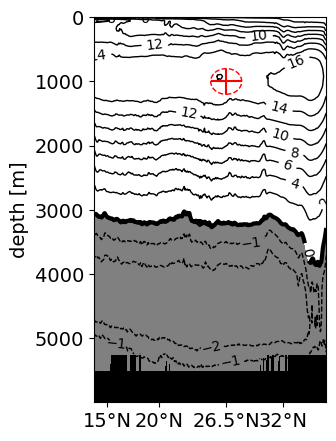

In [22]:
# set font size to 16
plt.rcParams.update({'font.size': 14})
fig = plt.figure(figsize=(3,5))
ax = fig.add_subplot(1,1,1)
stream_function = averaged_stream_function_both_cycles.isel(y = slice(1000,1500))
mask_mesh_sliced = mask_mesh.isel(y = slice(1000,1500))
ax.set_facecolor('black')
areas = ax.contourf(stream_function.squeeze().nav_lat, stream_function.squeeze().depthw, stream_function.squeeze().zomsfatl.where(mask_mesh_sliced.tmask.rename(z ='depthw').sum('x') > 100), levels = 0, colors = ['grey', 'white'])


zero_contour = ax.contour(stream_function.squeeze().nav_lat, stream_function.squeeze().depthw, stream_function.squeeze().zomsfatl.where(mask_mesh_sliced.tmask.rename(z ='depthw').sum('x') > 100), colors = 'black', levels = 0, linewidths = 3)

strike_contour = ax.contour(stream_function.squeeze().nav_lat, stream_function.squeeze().depthw, stream_function.squeeze().zomsfatl.where(mask_mesh_sliced.tmask.rename(z ='depthw').sum('x') > 100), colors = 'black', levels = [-2, -1] + list(range(2, 20, 2)), linewidths = 1)


ax.clabel(strike_contour, strike_contour.levels, inline=True, fontsize=10)
ax.clabel(zero_contour, zero_contour.levels, inline=True, fontsize=10)

ax.set_ylabel('depth [m]')

ax.set_xticks([-20, 15, 20, 26.5, 32, 60], ['20°S', '15°N', '20°N', '26.5°N', '32°N', '60°N'])

ax.set_yticks(np.arange(0, 6000, 1000) * -1,np.arange(0, 6000, 1000))

ax.vlines(26.5, -1200, -800, colors='red')
ax.hlines(-1000, 25, 28, colors='red')

from matplotlib.patches import Circle, Ellipse

ax.add_patch(Ellipse((26.5, -1000), 3, 400, alpha=1, facecolor ='none', edgecolor = 'red', linestyle = '--'))
ax.set_ylim(-6000, 0)

# ax.set_title('b) Stream function', loc='left', fontsize = 18)

In [ ]:
smoothed_antilles

In [23]:
ds_argo_merged.temperature.mean(['time','pos'])

<xarray.DataArray 'temperature' (z: 29)>
array([ 3.8714216,  4.1478157,  4.4789834,  4.883677 ,  5.282101 ,
        5.772092 ,  6.7381835,  8.506314 , 10.745922 , 12.9938965,
       14.984126 , 16.388622 , 17.377525 , 18.135706 , 18.785349 ,
       19.408077 , 20.032598 , 20.612776 , 21.109482 , 21.54526  ,
       21.984713 , 22.707174 , 22.707174 , 23.556246 , 23.556246 ,
       24.02476  , 24.02476  , 24.244661 , 24.244661 ], dtype=float32)
Coordinates:
  * z         (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    pressure  (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047

In [24]:
ds_argo_merged.where(ds_argo_merged.salinity > 30).salinity.isel(time = index_time).mean(['pos'])

NameError: name 'index_time' is not defined

In [ ]:
(((ds_argo_merged - ds_argo_merged.salinity.isel(time = index_time).mean(['pos'])) / ds_argo_merged.salinity.isel(time = index_time).mean(['pos']))).isel(time = index_time, pos = index_pos).sel(z = slice(-2000, None)).salinity

<xarray.DataArray 'salinity' (z: 29)>
array([ 5.4314727e-04,  4.2458382e-04, -4.6714704e-05, -7.4943434e-04,
       -5.5831391e-04,  8.1468321e-04,  2.8553000e-03,  3.9390610e-03,
        2.4398213e-04, -4.9541187e-03, -8.5555129e-03, -8.9632180e-03,
       -7.3432368e-03, -5.4342225e-03, -4.4224947e-03, -4.3574935e-03,
       -5.2513210e-03, -6.4647407e-03, -6.5649347e-03, -5.4627820e-03,
       -4.8572700e-03, -4.7784988e-03, -4.7784988e-03, -1.5364269e-03,
       -1.5364269e-03,  1.2798487e-03,  1.2798487e-03,  1.3963957e-03,
        1.3963957e-03], dtype=float32)
Coordinates:
    pos       int64 44
    time      datetime64[ns] 1849-12-20
  * z         (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lon       float32 -32.95
    lat       float32 28.15
    time_1d   datetime64[ns] 1849-07-04T12:00:00
    pressure  (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047

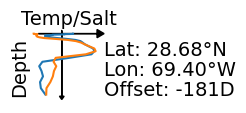

In [ ]:

# indices (0, 5), (50,46)
#50,2
# 0, 53
index_time = 50
index_pos = 2
pos_save = 1

from mpl_toolkits.axisartist.axislines import SubplotZero
fig = plt.figure(figsize=(1, 1))
ax = SubplotZero(fig, 111)
fig.add_subplot(ax)

(((ds_argo_merged -ds_argo_merged.temperature.isel(time = index_time).mean(['pos'])) / ds_argo_merged.temperature.isel(time = index_time).std(['pos']))).isel(time = index_time, pos = index_pos).sel(z = slice(-2000, None)).temperature.plot( y = 'z', ax = ax)
(((ds_argo_merged - ds_argo_merged.salinity.isel(time = index_time).mean(['pos'])) / ds_argo_merged.salinity.isel(time = index_time).std(['pos']))).isel(time = index_time, pos = index_pos).sel(z = slice(-2000, None)).salinity.plot( y = 'z', ax = ax)



ax.set_title(None)
ax.set_ylabel('Depth [m]')

# ax.axis['xzero'].set_axisline_style("-|>")
# ax.axis['xzero'].set_visible(True)



for direction in ["left", "right", "bottom", "top"]:
    # hides borders
    ax.axis[direction].set_visible(False)

# ax.axis['left'].set_axisline_style("-|>")
# ax.axis['left'].set_visible(True)


ax.arrow(0, 100, 0, -2000, head_width=.2, head_length=100, fc='k', ec='k')
ax.arrow(-1, 0, 2.5, 0, head_width=250, head_length=.3, fc='k', ec='k')

ax.text(0.3, 450, 'Temp/Salt', verticalalignment = 'center', horizontalalignment = 'center')
ax.text(-1.8, -1000, 'Depth',rotation = 90,  verticalalignment = 'center', horizontalalignment = 'center')

ax.text(1.8, -500, f'Lat: {ds_argo_merged.isel(time = index_time, pos = index_pos).lat.values[()]:.2f}°N', verticalalignment = 'center', horizontalalignment = 'left')
ax.text(1.8, -1100, f'Lon: {-ds_argo_merged.isel(time = index_time, pos = index_pos).lon.values[()]:.2f}°W', verticalalignment = 'center', horizontalalignment = 'left')
ax.text(1.8, -1700, f'Offset: {(ds_argo_merged.isel(time = index_time, pos = index_pos).time_1d - ds_argo_merged.isel(time = index_time, pos = index_pos).time).values.astype("timedelta64[D]").astype(int)}D', verticalalignment = 'center', horizontalalignment = 'left')

# fig.tight_layout()

plt.savefig(f'../rapid-geostrophic-reconstruction/figs/paperdraft/architecture/profile_{pos_save:02d}.png', dpi = 300,bbox_inches='tight')

In [ ]:
ds_argo_merged

<xarray.Dataset>
Dimensions:       (time: 487, pos: 691, z: 46)
Coordinates:
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 684 685 686 687 688 689 690
  * time          (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2090-01-01
  * z             (z) float32 -5.875e+03 -5.625e+03 -5.375e+03 ... -9.454 -3.047
    lon           (time, pos) float32 -38.15 -38.25 -38.35 ... nan nan nan
    lat           (time, pos) float32 25.02 25.06 25.11 25.11 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1970-04-08T12:00:00 ... NaT
    pressure      (z) float32 5.875e+03 5.625e+03 5.375e+03 ... 9.454 3.047
Data variables:
    temperature   (time, pos, z) float32 nan nan nan nan ... nan nan nan nan
    salinity      (time, pos, z) float32 nan nan nan nan ... nan nan nan nan
    profile_mask  (time, pos, z) float64 nan nan nan nan 1.0 ... nan nan nan nan
    ct            (time, pos, z) float64 nan nan nan nan ... nan nan nan nan
    rho           (time, pos, z) float64 nan nan nan nan ... nan nan nan nan

In [ ]:
ds_argo_merged_t

<xarray.Dataset>
Dimensions:       (pos: 691, z: 46)
Coordinates:
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 684 685 686 687 688 689 690
  * z             (z) float32 -5.875e+03 -5.625e+03 -5.375e+03 ... -9.454 -3.047
    pressure      (z) float32 5.875e+03 5.625e+03 5.375e+03 ... 9.454 3.047
Data variables:
    temperature   (pos, z) float32 nan nan 1.852 1.855 1.861 ... nan nan nan nan
    salinity      (pos, z) float32 nan nan 34.88 34.88 34.88 ... nan nan nan nan
    profile_mask  (pos, z) float64 nan nan 1.0 1.0 1.0 ... nan nan nan nan nan
    ct            (pos, z) float64 nan nan 1.852 1.854 1.861 ... nan nan nan nan
    rho           (pos, z) float64 nan nan 1.052e+03 1.051e+03 ... nan nan nan

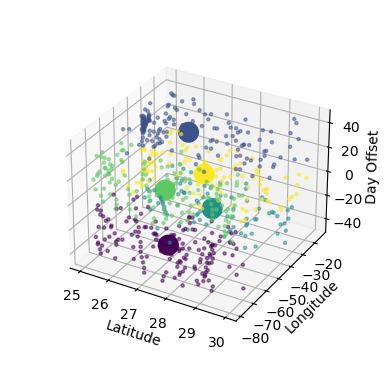

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

temporal_index = 56

import matplotlib.pyplot as plt
# Assuming you have latitudes, longitudes, and day offset data
latitudes = ds_argo_merged.isel(time = temporal_index).lat
longitudes = ds_argo_merged.isel(time = temporal_index).lon
day_offset = (ds_argo_merged.isel(time = temporal_index).time_1d - ds_argo_merged.isel(time = temporal_index).time).values.astype("timedelta64[D]").astype(int)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
valid_mask = day_offset > -1000
# ax.scatter(latitudes[valid_mask], longitudes[valid_mask], day_offset[valid_mask])

ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.set_zlabel('Day Offset')


from sklearn.cluster import KMeans  

kmeans = KMeans(n_clusters=5)

X = np.array([latitudes[valid_mask], longitudes[valid_mask], day_offset[valid_mask]]).T

kmeans.fit(X)

y_kmeans = kmeans.predict(X)

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_kmeans, s=5, cmap='viridis', alpha = .5)


centers = kmeans.cluster_centers_

ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2],c = np.arange(5), cmap='viridis', s=200, alpha=1)

# fig.tight_layout()

# zoom out to see the z label
ax.set_box_aspect(aspect=None, zoom=0.8)
# Make a 3 dimensional plot of latitudes, longitudes, and day offset

plt.savefig(f'../rapid-geostrophic-reconstruction/figs/paperdraft/architecture/cluster_{index_time}.png', dpi = 300,bbox_inches='tight')


In [ ]:
latitudes.values[q].shape

(691,)

In [ ]:
(ds_argo_merged.profile_mask.isel(time = index_time) == 1).any('z').sum()

<xarray.DataArray 'profile_mask' (pos: 691, z: 46)>
array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * pos       (pos) int64 0 1 2 3 4 5 6 7 8 ... 683 684 685 686 687 688 689 690
    time      datetime64[ns] 1970-04-01
  * z         (z) float32 -5.875e+03 -5.625e+03 -5.375e+03 ... -9.454 -3.047
    lon       (pos) float32 -38.15 -38.25 -38.35 -38.35 ... nan nan nan nan
    lat       (pos) float32 25.02 25.06 25.11 25.11 25.15 ... nan nan nan nan
    time_1d   (pos) datetime64[ns] 1970-04-08T12:00:00 ... NaT
    pressure  (z) float32 5.875e+03 5.625e+03 5.375e+03 ... 16.36 9.454 3.047

Text(0.0, 1.0, 'a) Windstress and Argo profiles')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:511: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)


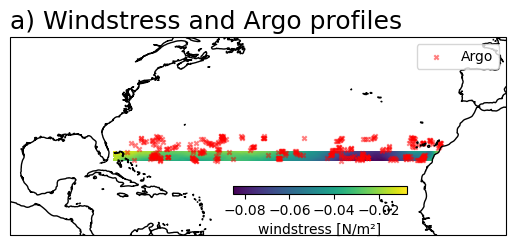

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection = ccrs.PlateCarree())

windstress = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/windstress/sozotaux_2527N_8010W_KFS003-1st_70None.nc')
monthly_windstress = windstress.groupby(windstress.time_counter.dt.floor('30D')).mean().rename({'floor': 'time'})

monthly_windstress = monthly_windstress.isel(time = 550)
taux = ax.pcolormesh(monthly_windstress.nav_lon, monthly_windstress.nav_lat, monthly_windstress.values, transform=ccrs.PlateCarree(), cmap = 'viridis')

ts = 110




ax.scatter(
    ds_argo_merged.isel(time = ts).where(ds_argo_merged.isel(time = ts).profile_mask.sum('z') > 0, drop = True).lon.values,
    ds_argo_merged.isel(time = ts).where(ds_argo_merged.isel(time = ts).profile_mask.sum('z') > 0, drop = True).lat.values,
    transform = ccrs.PlateCarree(),
    marker='x', s = 10, color = 'red', alpha=.5, label = 'Argo'
)

ax.legend()

ax.set_extent([-100,0,10,50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

# cax = ax.inset_axes([0.05, 0.05, 0.9, 0.25], transform=ax.transAxes)
cax = ax.inset_axes([0.45, 0.21, 0.35, 0.04])
fig.colorbar(taux, cax = cax, label = 'windstress [N/m²]', orientation='horizontal')

ax.set_title('a) Windstress and Argo profiles', loc='left', fontsize = 18)

[Text(0.5, 0, 'x'), Text(0.5, 0.5, 'y'), Text(0.5, 0, 'z')]

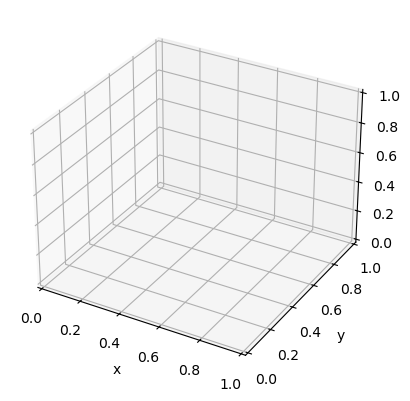

In [ ]:
from matplotlib.colors import Normalize


def imshow3d(ax, array, value_direction='z', pos=0, norm=None, cmap=None):
    """
    Display a 2D array as a  color-coded 2D image embedded in 3d.

    The image will be in a plane perpendicular to the coordinate axis *value_direction*.

    Parameters
    ----------
    ax : Axes3D
        The 3D Axes to plot into.
    array : 2D numpy array
        The image values.
    value_direction : {'x', 'y', 'z'}
        The axis normal to the image plane.
    pos : float
        The numeric value on the *value_direction* axis at which the image plane is
        located.
    norm : `~matplotlib.colors.Normalize`, default: Normalize
        The normalization method used to scale scalar data. See `imshow()`.
    cmap : str or `~matplotlib.colors.Colormap`, default: :rc:`image.cmap`
        The Colormap instance or registered colormap name used to map scalar data
        to colors.
    """
    if norm is None:
        norm = Normalize()
    colors = plt.get_cmap(cmap)(norm(array))

    if value_direction == 'x':
        nz, ny = array.shape
        zi, yi = np.mgrid[0:nz + 1, 0:ny + 1]
        xi = np.full_like(yi, pos)
    elif value_direction == 'y':
        nx, nz = array.shape
        xi, zi = np.mgrid[0:nx + 1, 0:nz + 1]
        yi = np.full_like(zi, pos)
    elif value_direction == 'z':
        ny, nx = array.shape
        yi, xi = np.mgrid[0:ny + 1, 0:nx + 1]
        zi = np.full_like(xi, pos)
    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")
    ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, facecolors=colors, shade=False)


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set(xlabel="x", ylabel="y", zlabel="z")


imshow3d


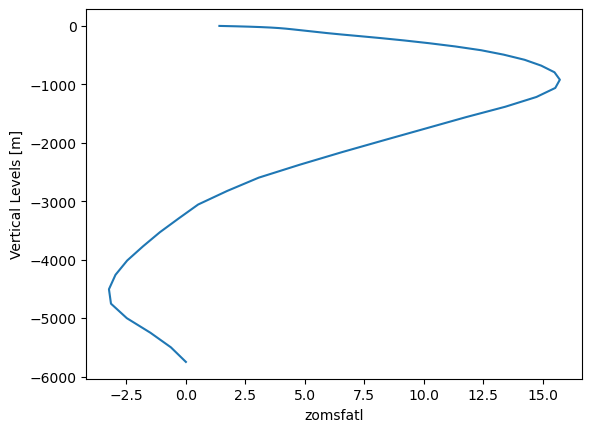

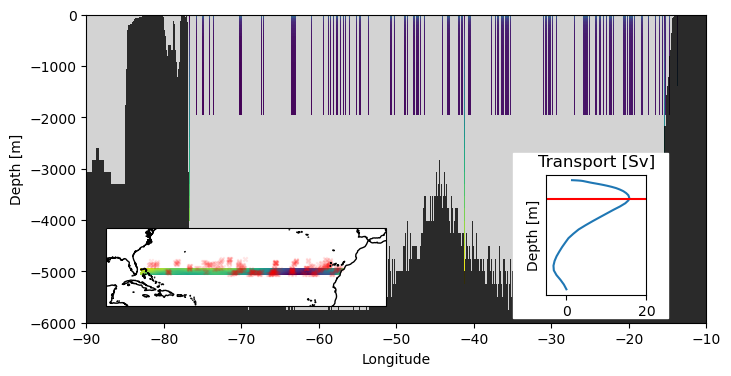

In [ ]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1,1,1)

# set the background color of the plot to white
ax.set_facecolor('lightgrey')

bottom = mask_mesh.tmask.isel(y = np.abs(mask_mesh.nav_lat.mean('x') - 26.5).argmin().values[()]).values.astype(np.float32)

bottom[bottom == 1] = np.NaN

rho = ax.pcolormesh(lon_bins, ds_argo_merged.z, nan_image.T, cmap = 'viridis')
ax.pcolormesh(lon_bins, ds_argo_merged.z, bottom, cmap = 'grey', alpha=.8)


# plt.colorbar(rho, ax = ax, label = 'Density')
ax.set_xlabel('Longitude')
ax.set_ylabel('Depth [m]')
ax.set_xlim(-90, -10)

# ax.set_title(f'{np.datetime_as_string(ds_argo_merged_10days.time[ts].values[()], unit="D")} - {np.datetime_as_string(ds_argo_merged_10days.time[ts+1].values[()], unit="D")}')


# for m in mooring_ds.moorings:
#     plt.text(m.nav_lon.values[()],100, m.values)

from cartopy import crs as ccrs
from cartopy import feature as cfeature


ax_inner = plt.axes([0.15, 0, .35, 0.5], projection=ccrs.PlateCarree(), transform = ax.transAxes, label='2')


# ax_inner = ax.inset_axes(
#     [0.1, 0.1, 0.1, 0.1], 
#     projection=ccrs.PlateCarree(),
#     transform=ax.transAxes, facecolor='white')

ax_inner.set_extent([-90,0,15,40], crs=ccrs.PlateCarree())

windstress = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/windstress/sozotaux_2527N_8010W_KFS003-1st_70None.nc')
monthly_windstress = windstress.groupby(windstress.time_counter.dt.floor('30D')).mean().rename({'floor': 'time'})

monthly_windstress = monthly_windstress.isel(time = 550)
taux = ax_inner.pcolormesh(monthly_windstress.nav_lon, monthly_windstress.nav_lat, monthly_windstress.values, transform=ccrs.PlateCarree(), cmap = 'viridis')

ax_inner.scatter(
    ds_argo_merged_10days.isel(time = ts).dropna('pos').lon.values,
    ds_argo_merged_10days.isel(time = ts).dropna('pos').lat.values,
    transform = ccrs.PlateCarree(),
    marker='x', s = 10, color = 'red', alpha=.1
)


ax_inner.add_feature(cfeature.COASTLINE)



# create rectangular patch 

from matplotlib.patches import Rectangle

# Create a Rectangle patch
rect = Rectangle((-35, -5900), 20, 3200, linewidth=1, edgecolor='white', facecolor='white')

# Add the patch to the Axes
ax.add_patch(rect)





ax_inner_moc = plt.axes([0.7, 0.18, .125, 0.3])

total_moc_ds.zomsfatl.mean('time').plot(y = 'depthw', ax = ax_inner_moc)

ax_inner_moc.set_yticks([])
ax_inner_moc.set_ylabel('Depth [m]')
ax_inner_moc.set_xlabel(None)
ax_inner_moc.set_title('Transport [Sv]')

ax_inner_moc.set_xlim(-5, 20)

ax_inner_moc.hlines(-1000, -5, 20, color = 'red')


plt.savefig('../rapid-geostrophic-reconstruction/figs/paperdraft/architecture/B_argo_profile.png', dpi = 300)

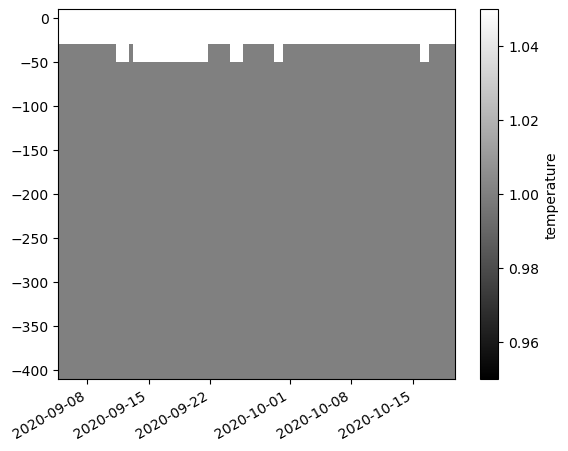

In [ ]:
ds_pos_obs = xr.open_dataset(dataset_path / ref_folder/ f'ds_pos_obs.nc')
dataslice = ds_pos_obs.isel(time = slice(12000, 12090)).temperature.isel(pos = 2).sel(z = slice(0, -400))


# make a binary mask of the data
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
mask = dataslice.notnull()

mask.where(mask).plot(cmap = 'gray' , ax = ax)

ax.set_title('')
ax.set_ylabel('')
ax.set_xlabel('')

plt.savefig('../rapid-geostrophic-reconstruction/figs/paperdraft/architecture/A_mask.png', dpi = 300)

In [ ]:
total_moc_path

PosixPath('../rapid-geostrophic-reconstruction/datasets/moc_total')

In [ ]:
ds = xr.open_dataset( total_moc_path/ f'cdf_moc_265N_KFS003-1st_7020.nc')

In [ ]:
# create an yearly averaged time series that has an value each 90 days like a moving average

moc_series_daily = ds.sel(depthw = -1000, method= 'nearest').zomsfatl


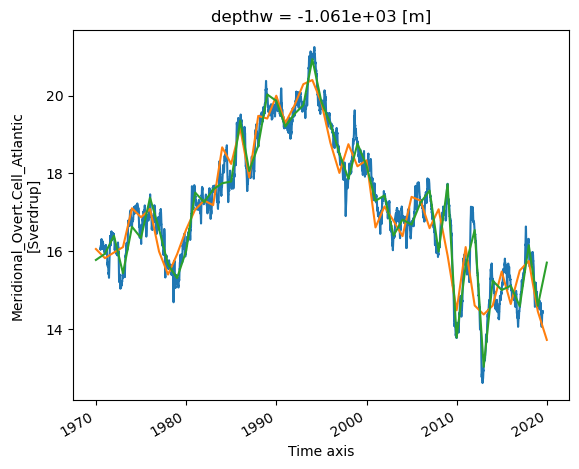

In [ ]:
# make a moving average of the time series
moc_series_daily.rolling(time_counter = 365, center = True).mean().plot()
moc_series_daily.resample(time_counter = '365D').mean().plot()
moc_series_daily.groupby(moc_series_daily.time_counter.dt.round('365D')).mean().rename({'round': 'time'}).plot()

In [ ]:
import xarray as xr
ds_1 = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/antilles_current/antilles_current_KFS003-1st_7024.nc')
ds_2 = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/antilles_current/antilles_current_KFS003-2nd_5824.nc')
ds_3 = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/antilles_current/antilles_current_KFS003-3rd_5824.nc')
ds_4 = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/antilles_current/antilles_current_KFS003-4th_5824.nc')
ds_5 = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/antilles_current/antilles_current_KFS003-5th_5824.nc')
ds_6 = xr.open_dataarray('../rapid-geostrophic-reconstruction/datasets/antilles_current/antilles_current_KFS003-6th_5824.nc')

In [ ]:
ds = xr.concat([ds_1, ds_2], dim = 'time_counter')

In [ ]:
import numpy as np
np.argwhere(ds.isnull().values).squeeze()

array([19747, 19748, 19749, ..., 43521, 43522, 43523])

In [ ]:
ds.isel(time_counter = slice(19747, None))

<xarray.DataArray (time_counter: 24082)>
array([       nan,        nan,        nan, ..., 6.10003691, 5.56168919,
       5.30961886])
Coordinates:
    time_centered  (time_counter) datetime64[ns] 1958-01-25T12:00:00 ... 2023...
  * time_counter   (time_counter) datetime64[ns] 1958-01-25T12:00:00 ... 2023...

In [ ]:
ds.isel(time_counter = slice(None, 43524))

<xarray.DataArray (time_counter: 43524)>
array([9.34438141, 8.19845764, 8.58635609, ...,        nan,        nan,
              nan])
Coordinates:
    time_centered  (time_counter) datetime64[ns] 1970-01-01T12:00:00 ... 2023...
  * time_counter   (time_counter) datetime64[ns] 1970-01-01T12:00:00 ... 2023...

In [ ]:
ds_2.isnull().sum()

<xarray.DataArray ()>
array(0)